# Visualization Pipeline — Diachronic Semantic Drift

## Project Context

This notebook is the **final stage** of the diachronic text analysis pipeline. It consumes the outputs produced by the three preceding stages and turns them into interpretable 2D visualisations and structured neighbor data.

The three preceding stages produced:

1. **Dataset** — Google Books N-grams (1900–2019) were downloaded, filtered, and aggregated into per-decade frequency files. A single shared vocabulary of 50,001 words (`vocab.json`) was built once across all decades by `build_vocab.py`, guaranteeing that every word maps to the same row index in every embedding matrix.

2. **Training** — One independent CBOW model was trained per decade (12 total, 1900s–2010s). Each model produces an embedding matrix of shape `(50001, 300)` saved as `emb_<decade>.pt`. Because models are initialised with random weights and trained in isolation, the 12 resulting embedding spaces are geometrically self-consistent but **arbitrarily rotated relative to one another**. Cosine similarity between vectors from two different decades is meaningless without first resolving this orientation mismatch.

3. **Alignment** — For each pair of consecutive decades `(t, t+1)`, an Orthogonal Procrustes rotation matrix `R` was estimated from high-frequency stable anchor words, minimising the Frobenius distance between their embeddings after mean-centering. Each pairwise transform is saved as `alignment_<t>_to_<t+1>.pt` and contains `R`, `mu_X` (source centroid), and `mu_Y` (target centroid).

## What This Notebook Does

This notebook is the direct translation into interactive form of the scripts in `src/visualization/`. It covers, in order:

| Stage | Source module | What happens |
|---|---|---|
| 1 | `drift_io.py` | Load shared vocabulary and per-decade embedding matrices |
| 2 | `alignment_utils.py` | Define and apply pairwise transforms; compose forward or backward to any reference decade |
| 3 | `visualize_drift.py` | Align all decades into the reference space; cache results |
| 4 | `neighbors.py` | Extract top-K nearest neighbors per word per decade; write CSVs |
| 5 | `visualize_drift.py` | Build trajectory matrix from aligned vectors |
| 6 | `visualize_drift.py` | Sample a background of 1,500 random vocab vectors from the reference decade to stabilise projections |
| 7 | `plotting.py` | Define the unified `plot_trajectory` function used for both PCA and t-SNE |
| 8 | `visualize_drift.py` + `plotting.py` | Fit PCA on background, project trajectories, plot |
| 9 | `visualize_drift.py` + `plotting.py` | Compute t-SNE on background + trajectories, extract trajectory slice, plot |
| 10 | `diachronic_associations.py` | Scatter plot of cosine similarity over time, annotated with neighbor words |

## Expected Inputs

| File | Produced by | Content |
|---|---|---|
| `VOCAB_FILE` | `build_vocab.py` | `vocab.json` — `word → index`, 50,001 entries |
| `MODELS_DIR/emb_<decade>.pt` | CBOW training | `embeddings.weight` tensor, shape (50001, 300) |
| `ALIGNMENT_TRANSFORMS_DIR/alignment_<t>_to_<t+1>.pt` | alignment notebook | tensors `R` (300×300), `mu_X` (1×300), `mu_Y` (1×300) |

## Setup — Imports and Paths

All filesystem paths are resolved from `src/config.py`, which is the single source of truth for the entire project. Importing from it guarantees that this notebook reads from and writes to exactly the same locations as every other script in the pipeline.

The four paths relevant to this stage are:
- **`MODELS_DIR`** — contains `emb_<decade>.pt`, one file per decade
- **`ALIGNMENT_TRANSFORMS_DIR`** — contains `alignment_<t>_to_<t+1>.pt`, one file per consecutive decade pair
- **`VOCAB_FILE`** — path to `vocab.json`
- **`PLOTS_DIR`** — output directory for all generated plots

`RESULTS_DIR` is a local directory created by this notebook to store the per-decade neighbor CSV files. `adjustText` is used by `plotting.py` and `plot_diachronic_associations_from_results.py` to automatically resolve label overlaps in scatter plots.

In [19]:
import json
import re
from pathlib import Path

import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from adjustText import adjust_text

from src.config import (
    DECADES,
    MODELS_DIR,
    VOCAB_FILE,
    ALIGNMENT_TRANSFORMS_DIR,
    PLOTS_DIR,
)

ALIGNMENT_DIR = Path(ALIGNMENT_TRANSFORMS_DIR)
PLOTS_DIR     = Path(PLOTS_DIR)
RESULTS_DIR   = Path("results")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Decades        :", len(DECADES), "—", DECADES[0], "→", DECADES[-1])
print("VOCAB_FILE     :", VOCAB_FILE)
print("MODELS_DIR     :", MODELS_DIR)
print("ALIGNMENT_DIR  :", ALIGNMENT_DIR)
print("PLOTS_DIR      :", PLOTS_DIR)
print("RESULTS_DIR    :", RESULTS_DIR)

Decades        : 12 — 1900s → 2010s
VOCAB_FILE     : /home/sperrotta/diachronic_text_analysis/data/processed/5gram/vocab.json
MODELS_DIR     : /home/sperrotta/diachronic_text_analysis/models/5gram-full
ALIGNMENT_DIR  : /home/sperrotta/diachronic_text_analysis/alignment/5gram/transforms
PLOTS_DIR      : /home/sperrotta/diachronic_text_analysis/plots
RESULTS_DIR    : results


## Runtime Parameters

All parameters that control the pipeline are defined here. No other cell needs to be modified for a different run.

- **`TARGET_WORDS`** — words whose semantic trajectories will be visualised. Must be present in the shared vocabulary. Best results come from words with expected semantic drift, such as technology terms or culturally charged words.

- **`REFERENCE_DECADE`** — the decade whose vector space is used as the common reference. All embeddings are projected into this space. Set to `2010s` as the most recent, highest-quality decade, making results most interpretable relative to the present.

- **`COMPUTE_NEIGHBORS`** — if `True`, top-`TOP_K` nearest neighbors are computed for every target word in every decade and written to `RESULTS_DIR/neighbors_<decade>.csv`. These CSVs are also required by the diachronic associations plot in Stage 10.

- **`TOP_K`** — number of nearest neighbors to extract per word per decade.

- **`RUN_PCA`** / **`RUN_TSNE`** — enable or disable each projection independently.

- **`CONNECT`** — if `True`, consecutive decade points of the same word are connected with a polyline, tracing the semantic trajectory across time.

- **`BACKGROUND_N`** — number of random vocabulary vectors sampled from the reference decade and used to stabilise PCA and t-SNE. PCA is fit on these background vectors (not on the trajectory), preventing the projection from being dominated by the few target words. t-SNE is computed on background + trajectory together, then only trajectory points are plotted. `0` disables background (not recommended for small word sets).

- **`SEED`** — random seed for background sampling, PCA, and t-SNE. Fixes reproducibility across runs.

- **`PERPLEXITY`** — t-SNE perplexity. `None` triggers auto-computation as `min(30, (n_total - 1) // 3)` where `n_total = BACKGROUND_N + len(TARGET_WORDS) * len(DECADES)`.

- **`PCA_SINGLE_WORD`** / **`TSNE_SINGLE_WORD`** — if `True`, in addition to the multi-word plot, a separate PCA/t-SNE plot is generated for each word in `TARGET_WORDS` individually.

- **`DIACHRONIC_WINDOWS`** — list of `(from_decade, to_decade)` tuples. For each tuple, a separate diachronic associations plot is produced restricted to that decade range, in addition to the full-range plot. Each element can also be `(None, None)` to mean the full range explicitly.

In [20]:
TARGET_WORDS     = ["computer", "internet", "cloud"]
REFERENCE_DECADE = "2010s"

COMPUTE_NEIGHBORS = True
TOP_K             = 10

RUN_PCA  = True
RUN_TSNE = True

CONNECT      = True
BACKGROUND_N = 1500
SEED         = 0
PERPLEXITY   = None   # None = auto

PCA_SINGLE_WORD  = True
TSNE_SINGLE_WORD = True

DIACHRONIC_TOPK = 6       
DIACHRONIC_WINDOWS = [
    ("1910s", "1960s"),
    ("1970s", "2010s"),
]

print("TARGET_WORDS      :", TARGET_WORDS)
print("REFERENCE_DECADE  :", REFERENCE_DECADE)
print("TOP_K             :", TOP_K)
print("BACKGROUND_N      :", BACKGROUND_N)
print("SEED              :", SEED)
print("PCA_SINGLE_WORD   :", PCA_SINGLE_WORD)
print("TSNE_SINGLE_WORD  :", TSNE_SINGLE_WORD)
print("DIACHRONIC_WINDOWS:", DIACHRONIC_WINDOWS)

TARGET_WORDS      : ['computer', 'internet', 'cloud']
REFERENCE_DECADE  : 2010s
TOP_K             : 10
BACKGROUND_N      : 1500
SEED              : 0
PCA_SINGLE_WORD   : True
TSNE_SINGLE_WORD  : True
DIACHRONIC_WINDOWS: [('1910s', '1960s'), ('1970s', '2010s')]


## Stage 1 — Data Loading (`drift_io.py`)

This stage provides the two primitive data types that all subsequent stages depend on.

**`load_vocab`** reads `vocab.json` and returns the `word → index` mapping. The vocabulary was built once across the full cross-decade corpus by `build_vocab.py` and is shared by all 12 CBOW models. This shared index mapping is the critical invariant that makes cross-decade comparison possible: row `i` of `emb_1900s.pt` and row `i` of `emb_1990s.pt` always represent the same word. The inverse mapping `inv_vocab` is built here for use during neighbor extraction, when row indices must be converted back to human-readable word strings.

**`load_embedding_matrix`** loads `emb_<decade>.pt` and extracts `embeddings.weight` — the input embedding layer of the CBOW model. This is a matrix of shape `(50001, 300)` where each row is the 300-dimensional vector for one vocabulary word as learned from the n-gram co-occurrences of that decade. The tensor is moved to CPU and converted to NumPy.

In [21]:
def load_vocab(vocab_path: Path) -> dict:
    with open(vocab_path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_embedding_matrix(models_dir: Path, decade: str) -> np.ndarray:
    pt_path = models_dir / f"emb_{decade}.pt"
    if not pt_path.exists():
        raise FileNotFoundError(f"Missing embedding file: {pt_path}")

    state_dict = torch.load(pt_path, map_location="cpu")
    key = "embeddings.weight"
    if key not in state_dict:
        raise KeyError(f"Key '{key}' not found in {pt_path}. Keys={list(state_dict.keys())}")

    return state_dict[key].detach().cpu().numpy()

In [22]:
vocab     = load_vocab(VOCAB_FILE)
inv_vocab = {idx: w for w, idx in vocab.items()}

print(f"Vocabulary size : {len(vocab):,}")

missing = [w for w in TARGET_WORDS if w not in vocab]
if missing:
    raise ValueError(f"Words not found in vocabulary: {missing}")
print(f"All target words found: {TARGET_WORDS}")

Vocabulary size : 50,002
All target words found: ['computer', 'internet', 'cloud']


## Stage 2 — Alignment Helpers (`alignment_utils.py`)

### Why alignment is necessary

The 12 CBOW models were trained independently. Each converges to a geometrically consistent internal configuration — semantically similar words are close together — but the absolute orientation of the resulting 300-dimensional space is arbitrary. There is no mechanism that forces "computer" in the 1930s model to point in the same direction as "computer" in the 1990s model. Computing cosine similarity between vectors from different decades without first aligning the spaces would conflate genuine semantic change with arbitrary rotational differences between training runs.

The alignment stage resolved this by computing, for each consecutive decade pair `(t, t+1)`, an Orthogonal Procrustes rotation matrix `R` from high-frequency anchor words assumed to be semantically stable across adjacent decades. Each transform is stored in `alignment_<t>_to_<t+1>.pt` with three tensors:
- **`R`** — orthogonal rotation matrix (300×300), computed via SVD
- **`mu_X`** — mean centroid of anchor embeddings in source decade `t`, shape (1×300)
- **`mu_Y`** — mean centroid of anchor embeddings in target decade `t+1`, shape (1×300)

### The per-step transform formula

`apply_pair_transform` applies one step of forward alignment:
```
E_aligned = (E - mu_X) @ R + mu_Y
```
Subtracting `mu_X` centers the source embeddings before rotation; adding `mu_Y` re-centers them in the target coordinate system. This handles the translational offset between the two anchor centroids, which rotation alone cannot resolve.

`apply_pair_inverse_transform` inverts this operation. Because `R` is orthogonal by construction, its inverse is simply its transpose `R.T`:
```
E_back = (E_aligned - mu_Y) @ R.T + mu_X
```

### Forward and backward composition

`align_embeddings_to_ref` composes pairwise transforms from `decade` to `ref_decade`. Unlike the previous version of the module, this implementation supports **both directions**:
- **Forward** (`decade < ref_decade`): chains `T_t→t+1` steps sequentially
- **Backward** (`decade > ref_decade`): chains inverse transforms in reverse order
- **Identity** (`decade == ref_decade`): returns the matrix unchanged

This bidirectional support allows choosing any decade — not just `2010s` — as reference.

In [23]:
def load_alignment_pair(alignment_dir: Path, dec_from: str, dec_to: str) -> dict:
    p = alignment_dir / f"alignment_{dec_from}_to_{dec_to}.pt"
    if not p.exists():
        raise FileNotFoundError(f"Missing alignment file: {p}")

    obj = torch.load(p, map_location="cpu")
    for k in ("R", "mu_X", "mu_Y"):
        if k not in obj:
            raise KeyError(f"Missing key '{k}' in {p}")
    return obj


def apply_pair_transform(E: np.ndarray, R: torch.Tensor,
                         mu_X: torch.Tensor, mu_Y: torch.Tensor) -> np.ndarray:
    Rn = R.detach().cpu().numpy()
    mx = mu_X.detach().cpu().numpy()
    my = mu_Y.detach().cpu().numpy()
    return (E - mx) @ Rn + my


def apply_pair_inverse_transform(E_to: np.ndarray, R: torch.Tensor,
                                 mu_X: torch.Tensor, mu_Y: torch.Tensor) -> np.ndarray:
    Rn = R.detach().cpu().numpy()
    mx = mu_X.detach().cpu().numpy()
    my = mu_Y.detach().cpu().numpy()
    return (E_to - my) @ Rn.T + mx


def align_embeddings_to_ref(alignment_dir: Path, E_dec: np.ndarray,
                             decade: str, ref_decade: str) -> np.ndarray:
    if decade not in DECADES:
        raise ValueError(f"decade={decade} not in DECADES={DECADES}")
    if ref_decade not in DECADES:
        raise ValueError(f"ref_decade={ref_decade} not in DECADES={DECADES}")

    i = DECADES.index(decade)
    j = DECADES.index(ref_decade)
    E = E_dec

    if i == j:
        return E

    # Forward: compose transforms decade -> ref_decade
    if i < j:
        for k in range(i, j):
            T = load_alignment_pair(alignment_dir, DECADES[k], DECADES[k + 1])
            E = apply_pair_transform(E, T["R"], T["mu_X"], T["mu_Y"])
        return E

    # Backward: apply inverse transforms in reverse order
    for k in range(i - 1, j - 1, -1):
        T = load_alignment_pair(alignment_dir, DECADES[k], DECADES[k + 1])
        E = apply_pair_inverse_transform(E, T["R"], T["mu_X"], T["mu_Y"])

    return E

## Stage 3 — Aligning All Decades to the Reference (`visualize_drift.py`)

This loop is the core data preparation step. For each of the 12 decades, the embedding matrix is loaded from disk and the appropriate sequence of pairwise transforms is applied via `align_embeddings_to_ref`, mapping the matrix into the vector space of `REFERENCE_DECADE`.

After this loop, `aligned_by_decade` is a dictionary mapping each decade string to its aligned `(50001, 300)` NumPy array. All 12 matrices now share a common coordinate system. From this point forward, cosine similarity computed between vectors from different decades is a semantically meaningful measurement: a value close to 1.0 means the word was used in similar contexts in both periods; a substantially lower value signals that the word's distributional neighbourhood — and therefore its meaning — has shifted.

If `COMPUTE_NEIGHBORS` is enabled, the neighbor CSV for each decade is also written inside this loop, immediately after alignment, so the aligned matrix is available without needing to be re-loaded.

In [24]:
aligned_by_decade = {}

for decade in DECADES:
    E_dec     = load_embedding_matrix(MODELS_DIR, decade)
    E_aligned = align_embeddings_to_ref(ALIGNMENT_DIR, E_dec, decade, REFERENCE_DECADE)
    aligned_by_decade[decade] = E_aligned
    print(f"  {decade}  aligned  shape={E_aligned.shape}")

print(f"\nAll {len(aligned_by_decade)} decades aligned into '{REFERENCE_DECADE}' space.")

  1900s  aligned  shape=(50002, 300)
  1910s  aligned  shape=(50002, 300)
  1920s  aligned  shape=(50002, 300)
  1930s  aligned  shape=(50002, 300)
  1940s  aligned  shape=(50002, 300)
  1950s  aligned  shape=(50002, 300)
  1960s  aligned  shape=(50002, 300)
  1970s  aligned  shape=(50002, 300)
  1980s  aligned  shape=(50002, 300)
  1990s  aligned  shape=(50002, 300)
  2000s  aligned  shape=(50002, 300)
  2010s  aligned  shape=(50002, 300)

All 12 decades aligned into '2010s' space.


## Stage 4 — Nearest Neighbors (`neighbors.py`)

Nearest neighbor extraction provides a **qualitative, human-readable account of semantic change** alongside the geometric measurements. Rather than a single cosine distance number, it shows which words surrounded a target word in each decade — making the nature of the shift directly interpretable.

The documented expected evolution of "computer" illustrates this: in the 1930s its neighbors reflect the original meaning (*calculator*, *mathematician*, *clerk* — a person who computes), while in the 1990s they reflect the modern technological meaning (*software*, *hardware*, *digital*).

### `cosine_topk`

Computes cosine similarity between a single query vector and every row of the aligned embedding matrix. Both the query and the matrix rows are L2-normalised before the dot product. The query word's own index is excluded by setting its similarity score to `-inf`. Top-K indices are identified with `np.argpartition` (O(n) partial sort) and then sorted only within that small subset, avoiding a full O(n log n) sort over 50,001 entries.

### `write_neighbors_csv`

Calls `cosine_topk` for every target word in the given decade and writes the ranked results to `RESULTS_DIR/neighbors_<decade>.csv` with columns `word, decade, rank, neighbor, cosine`. Words not present in the vocabulary are silently skipped. One file is produced per decade (12 files total for the full pipeline).

In [25]:
def cosine_topk(vec: np.ndarray, mat: np.ndarray, k: int,
                exclude_index: int | None = None):
    vec_n = vec / np.linalg.norm(vec)
    mat_n = mat / np.linalg.norm(mat, axis=1, keepdims=True)
    sims  = mat_n @ vec_n

    if exclude_index is not None:
        sims[exclude_index] = -np.inf

    idx = np.argpartition(-sims, k)[:k]
    idx = idx[np.argsort(-sims[idx])]
    return idx, sims[idx]


def write_neighbors_csv(out_csv, words, decade, vocab, inv_vocab, E_aligned, topk):
    with open(out_csv, "w", encoding="utf-8") as f:
        f.write("word,decade,rank,neighbor,cosine\n")
        for w in words:
            if w not in vocab:
                continue
            wi = vocab[w]
            idx, sims = cosine_topk(E_aligned[wi], E_aligned, k=topk, exclude_index=wi)
            for r, (ni, s) in enumerate(zip(idx, sims), start=1):
                f.write(f"{w},{decade},{r},{inv_vocab[ni]},{float(s)}\n")

In [26]:
if COMPUTE_NEIGHBORS:
    for decade in DECADES:
        out_csv = RESULTS_DIR / f"neighbors_{decade}.csv"
        write_neighbors_csv(
            out_csv   = out_csv,
            words     = TARGET_WORDS,
            decade    = decade,
            vocab     = vocab,
            inv_vocab = inv_vocab,
            E_aligned = aligned_by_decade[decade],
            topk      = TOP_K,
        )
    print(f"Neighbor CSVs written to: {RESULTS_DIR}")
    print(f"Files: {len(list(RESULTS_DIR.glob('neighbors_*.csv')))} (one per decade)")
else:
    print("COMPUTE_NEIGHBORS=False — skipping.")

Neighbor CSVs written to: results
Files: 12 (one per decade)


## Stage 5 — Building the Trajectory Matrix (`visualize_drift.py`)

Before PCA or t-SNE can be applied, the aligned target word vectors must be collected into a single matrix `X_traj`. Both projection methods require all points to be present simultaneously in order to compute a globally consistent 2D layout. Applying PCA or t-SNE separately per word would produce incomparable coordinate systems.

The row layout follows the ordering expected by `plot_trajectory` in `plotting.py`:

```
for decade in DECADES:
    for word in TARGET_WORDS:
        append aligned vector for (word, decade)
```

This means the row at index `di * len(TARGET_WORDS) + wi` corresponds to word `wi` in decade `di`. The final shape of `X_traj` is `(len(TARGET_WORDS) * len(DECADES), 300)`.

In [27]:
points_all = []
for decade in DECADES:
    E_aligned = aligned_by_decade[decade]
    for w in TARGET_WORDS:
        points_all.append(E_aligned[vocab[w]])

X_traj = np.vstack(points_all)
print(f"X_traj shape: {X_traj.shape}")
print(f"  = {len(TARGET_WORDS)} words × {len(DECADES)} decades × 300 dimensions")

X_traj shape: (36, 300)
  = 3 words × 12 decades × 300 dimensions


## Stage 6 — Background Sampling for Projection Stability (`visualize_drift.py`)

When PCA or t-SNE is computed on only a handful of points (e.g. 3 words × 12 decades = 36 points), the resulting projection is highly sensitive to the specific words chosen: the principal components of PCA will be dominated by those few vectors, and t-SNE will produce an arbitrary layout with little structural meaning.

`_pick_background_indices` addresses this by sampling `BACKGROUND_N` random vocabulary indices from the reference decade's aligned embedding matrix. Target word indices are excluded from sampling so they do not appear twice in the projection input.

The background is used differently by each method:
- **PCA** — `fit` is called on the background vectors only. The principal components capture the global variance structure of the full vocabulary in the reference space. The trajectory points are then `transform`ed into this stable coordinate system.
- **t-SNE** — the background is prepended to the trajectory matrix before calling `fit_transform`. After the 2D embedding is computed, only the trajectory rows (at indices `offset:`) are extracted and plotted. The background provides t-SNE with sufficient neighbourhood density to produce a stable, meaningful layout.

In [28]:
def _pick_background_indices(vocab_size: int, exclude: set, n: int, seed: int = 0) -> np.ndarray:
    rng        = np.random.default_rng(seed)
    candidates = np.array([i for i in range(vocab_size) if i not in exclude], dtype=int)
    if len(candidates) == 0:
        return np.array([], dtype=int)
    n = min(n, len(candidates))
    return rng.choice(candidates, size=n, replace=False)

In [29]:
E_ref   = aligned_by_decade[REFERENCE_DECADE]
exclude = {vocab[w] for w in TARGET_WORDS}

bg_idx = _pick_background_indices(E_ref.shape[0], exclude=exclude, n=BACKGROUND_N, seed=SEED)
X_bg   = E_ref[bg_idx] if len(bg_idx) > 0 else None

print(f"Reference decade embedding matrix : {E_ref.shape}")
print(f"Background indices sampled        : {len(bg_idx)}")
print(f"Background matrix shape           : {X_bg.shape if X_bg is not None else 'None'}")

Reference decade embedding matrix : (50002, 300)
Background indices sampled        : 1500
Background matrix shape           : (1500, 300)


## Stage 7 — Plotting Helper (`plotting.py`)

`plotting.py` exposes a single unified function `plot_trajectory` used for both PCA and t-SNE output. This replaces the two separate functions (`plot_pca_window`, `plot_tsne`) present in the earlier version of the module.

**`_expand_axes(ax, X, frac)`** — expands the axis limits by a fraction `frac` of the data range on each side. This gives `adjustText` room to resolve label overlaps without pushing labels outside the visible plot area. If all points share the same coordinate on either axis (degenerate case), the range is forced to 1.0 to avoid zero-width axes.

**`plot_trajectory(X2, words, title, out_path, connect, xlabel, ylabel)`** — renders the 2D scatter plot for the trajectory points in `X2`. Key behaviours:

- The expected row ordering of `X2` is: for each word (outer), for each decade (inner), one row per `(word, decade)` pair. This is the same ordering produced by Stage 5.
- Each word receives a distinct color from the matplotlib default cycle.
- If `connect=True`, consecutive decade points are joined by a polyline (drawn at `zorder=1`, behind scatter points at `zorder=2`), tracing the semantic trajectory across time.
- Decade labels are placed at each point and collected into a `texts` list. `adjust_text` then resolves overlaps by repelling labels from each other and from data points, drawing thin gray connector lines (`arrowstyle="-"`) from each moved label back to its original point. Data point positions are never moved.
- `_expand_axes` is called **before** `adjust_text` so that the enlarged axis bounds give the label-repulsion algorithm room to operate.
- `fig.tight_layout()` is called to minimise whitespace while respecting the final label extents after adjustment. The figure is saved at 300 DPI and immediately closed to prevent memory accumulation across multiple calls.

In [30]:
def _expand_axes(ax, X, frac=0.25):
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    dx = xmax - xmin or 1.0
    dy = ymax - ymin or 1.0
    ax.set_xlim(xmin - frac * dx, xmax + frac * dx)
    ax.set_ylim(ymin - frac * dy, ymax + frac * dy)


def plot_trajectory(X2: np.ndarray, words: list, title: str, out_path,
                    connect: bool = True, xlabel: str = "dim1", ylabel: str = "dim2"):
    n_dec   = len(DECADES)
    cmap    = plt.cm.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(13, 9))
    texts   = []

    for wi, w in enumerate(words):
        color  = cmap(wi % 10)
        idxs   = [wi * n_dec + di for di in range(n_dec)]
        pts    = X2[idxs]

        # ── scatter with alpha gradient: older = lighter, newer = darker ──
        n = len(pts)
        for di, (x, y) in enumerate(pts):
            alpha = 0.3 + 0.7 * (di / max(n - 1, 1))
            ax.scatter(x, y, s=50, color=color,
                       alpha=alpha, zorder=2,
                       label=w if (len(words) > 1 and di == 0) else None)

        # ── arrows between consecutive decades ──
        if connect:
            for di in range(n - 1):
                x0, y0 = pts[di]
                x1, y1 = pts[di + 1]
                ax.annotate("",
                    xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color=color,
                        lw=1.0,
                        mutation_scale=10,
                    ),
                    zorder=1,
                )

        # ── decade labels ──
        for di, dec in enumerate(DECADES):
            texts.append(ax.text(pts[di, 0], pts[di, 1], dec,
                                 fontsize=8, zorder=3,
                                 color=color))

    _expand_axes(ax, X2, frac=0.30)
    adjust_text(texts, ax=ax,
                expand_points=(1.3, 1.5), expand_text=(1.3, 1.5),
                arrowprops=dict(arrowstyle="-", lw=0.3, color="gray"))

    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if len(words) > 1:
        ax.legend(loc="best", fontsize=9)

    # ── colorbar legend for time direction ──
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Greys,
                                norm=plt.Normalize(vmin=int(DECADES[0][:4]),
                                                   vmax=int(DECADES[-1][:4])))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label("Decade (darker = more recent)", fontsize=8)

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)
    print(f"Plot saved → {out_path}")

## Stage 8 — PCA Projection and Plot (`visualize_drift.py` + `plotting.py`)

PCA reduces the 300-dimensional aligned space to 2D by finding the two orthogonal directions of maximum variance.

**Fit on background, transform trajectory.** When `X_bg` is available, PCA is `fit` on the background vectors only. This is a deliberate design choice: the principal components are derived from a representative sample of the full vocabulary in the reference space, not from the handful of target words. This makes the coordinate axes stable and independent of which words are being analysed. The trajectory points are then `transform`ed into this pre-computed coordinate system. If no background is available (fallback), `fit_transform` is called on the trajectory itself.

**Explained variance.** The ratio printed after fitting indicates how much of the original 300-dimensional variance is captured by the two axes. A combined ratio above ~0.30 is generally sufficient for trajectory analysis.

**Interpreting the plot.** With `CONNECT=True`, each word traces a polyline. A short, compact trajectory indicates semantic stability over the displayed period. A long, directional line indicates gradual monotonic drift. A non-linear or bent path indicates that the semantic shift was not uniform — there was a specific period of rapid change.

**Output filename** follows the convention: `pca_<words>_ref_<ref_decade>_win_<from>_<to>.png`.

When `PCA_SINGLE_WORD=True`, after the multi-word plot, an additional plot is produced for each word individually. For a single word, PCA is fit on the background and only that word's 12 decade points are transformed and plotted. The output is named `pca_<word>_ref_<ref_decade>_win_ALL_ALL.png`.

Explained variance: PC1=12.3%  PC2=3.0%  total=15.3%


/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/pca_computer_internet_cloud_ref_2010s_win_ALL_ALL.png


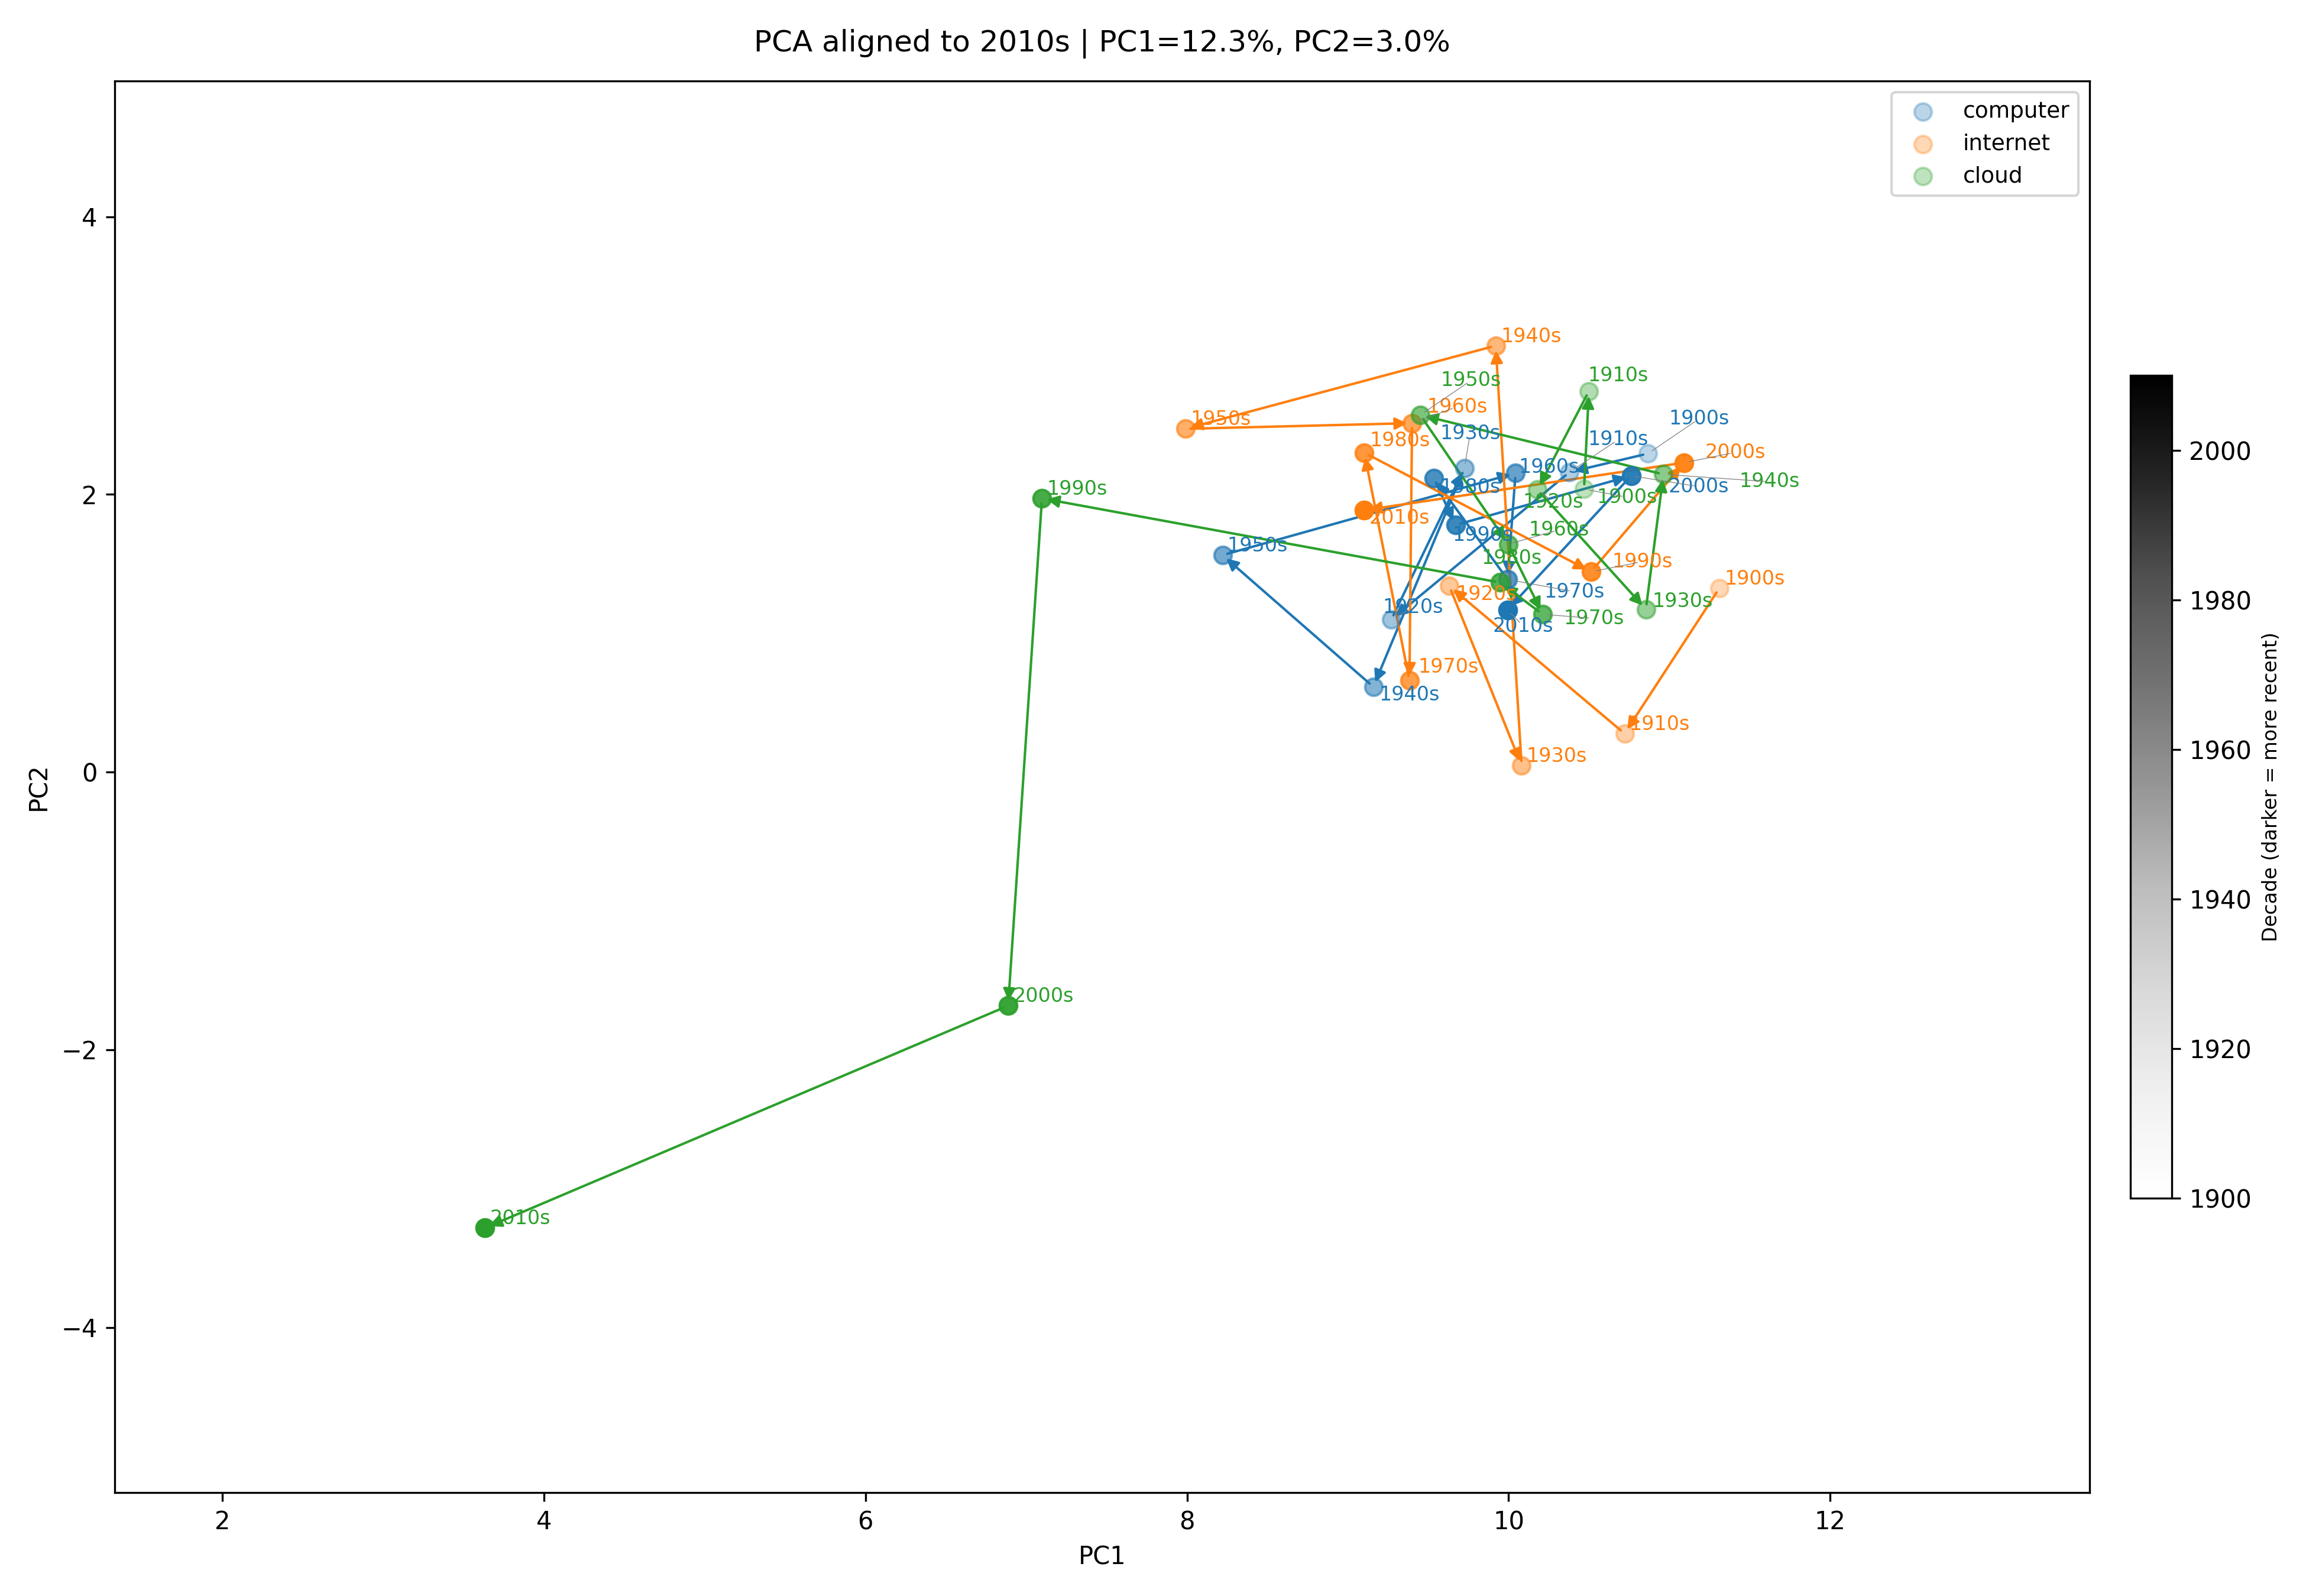

/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/pca_computer_ref_2010s_win_ALL_ALL.png


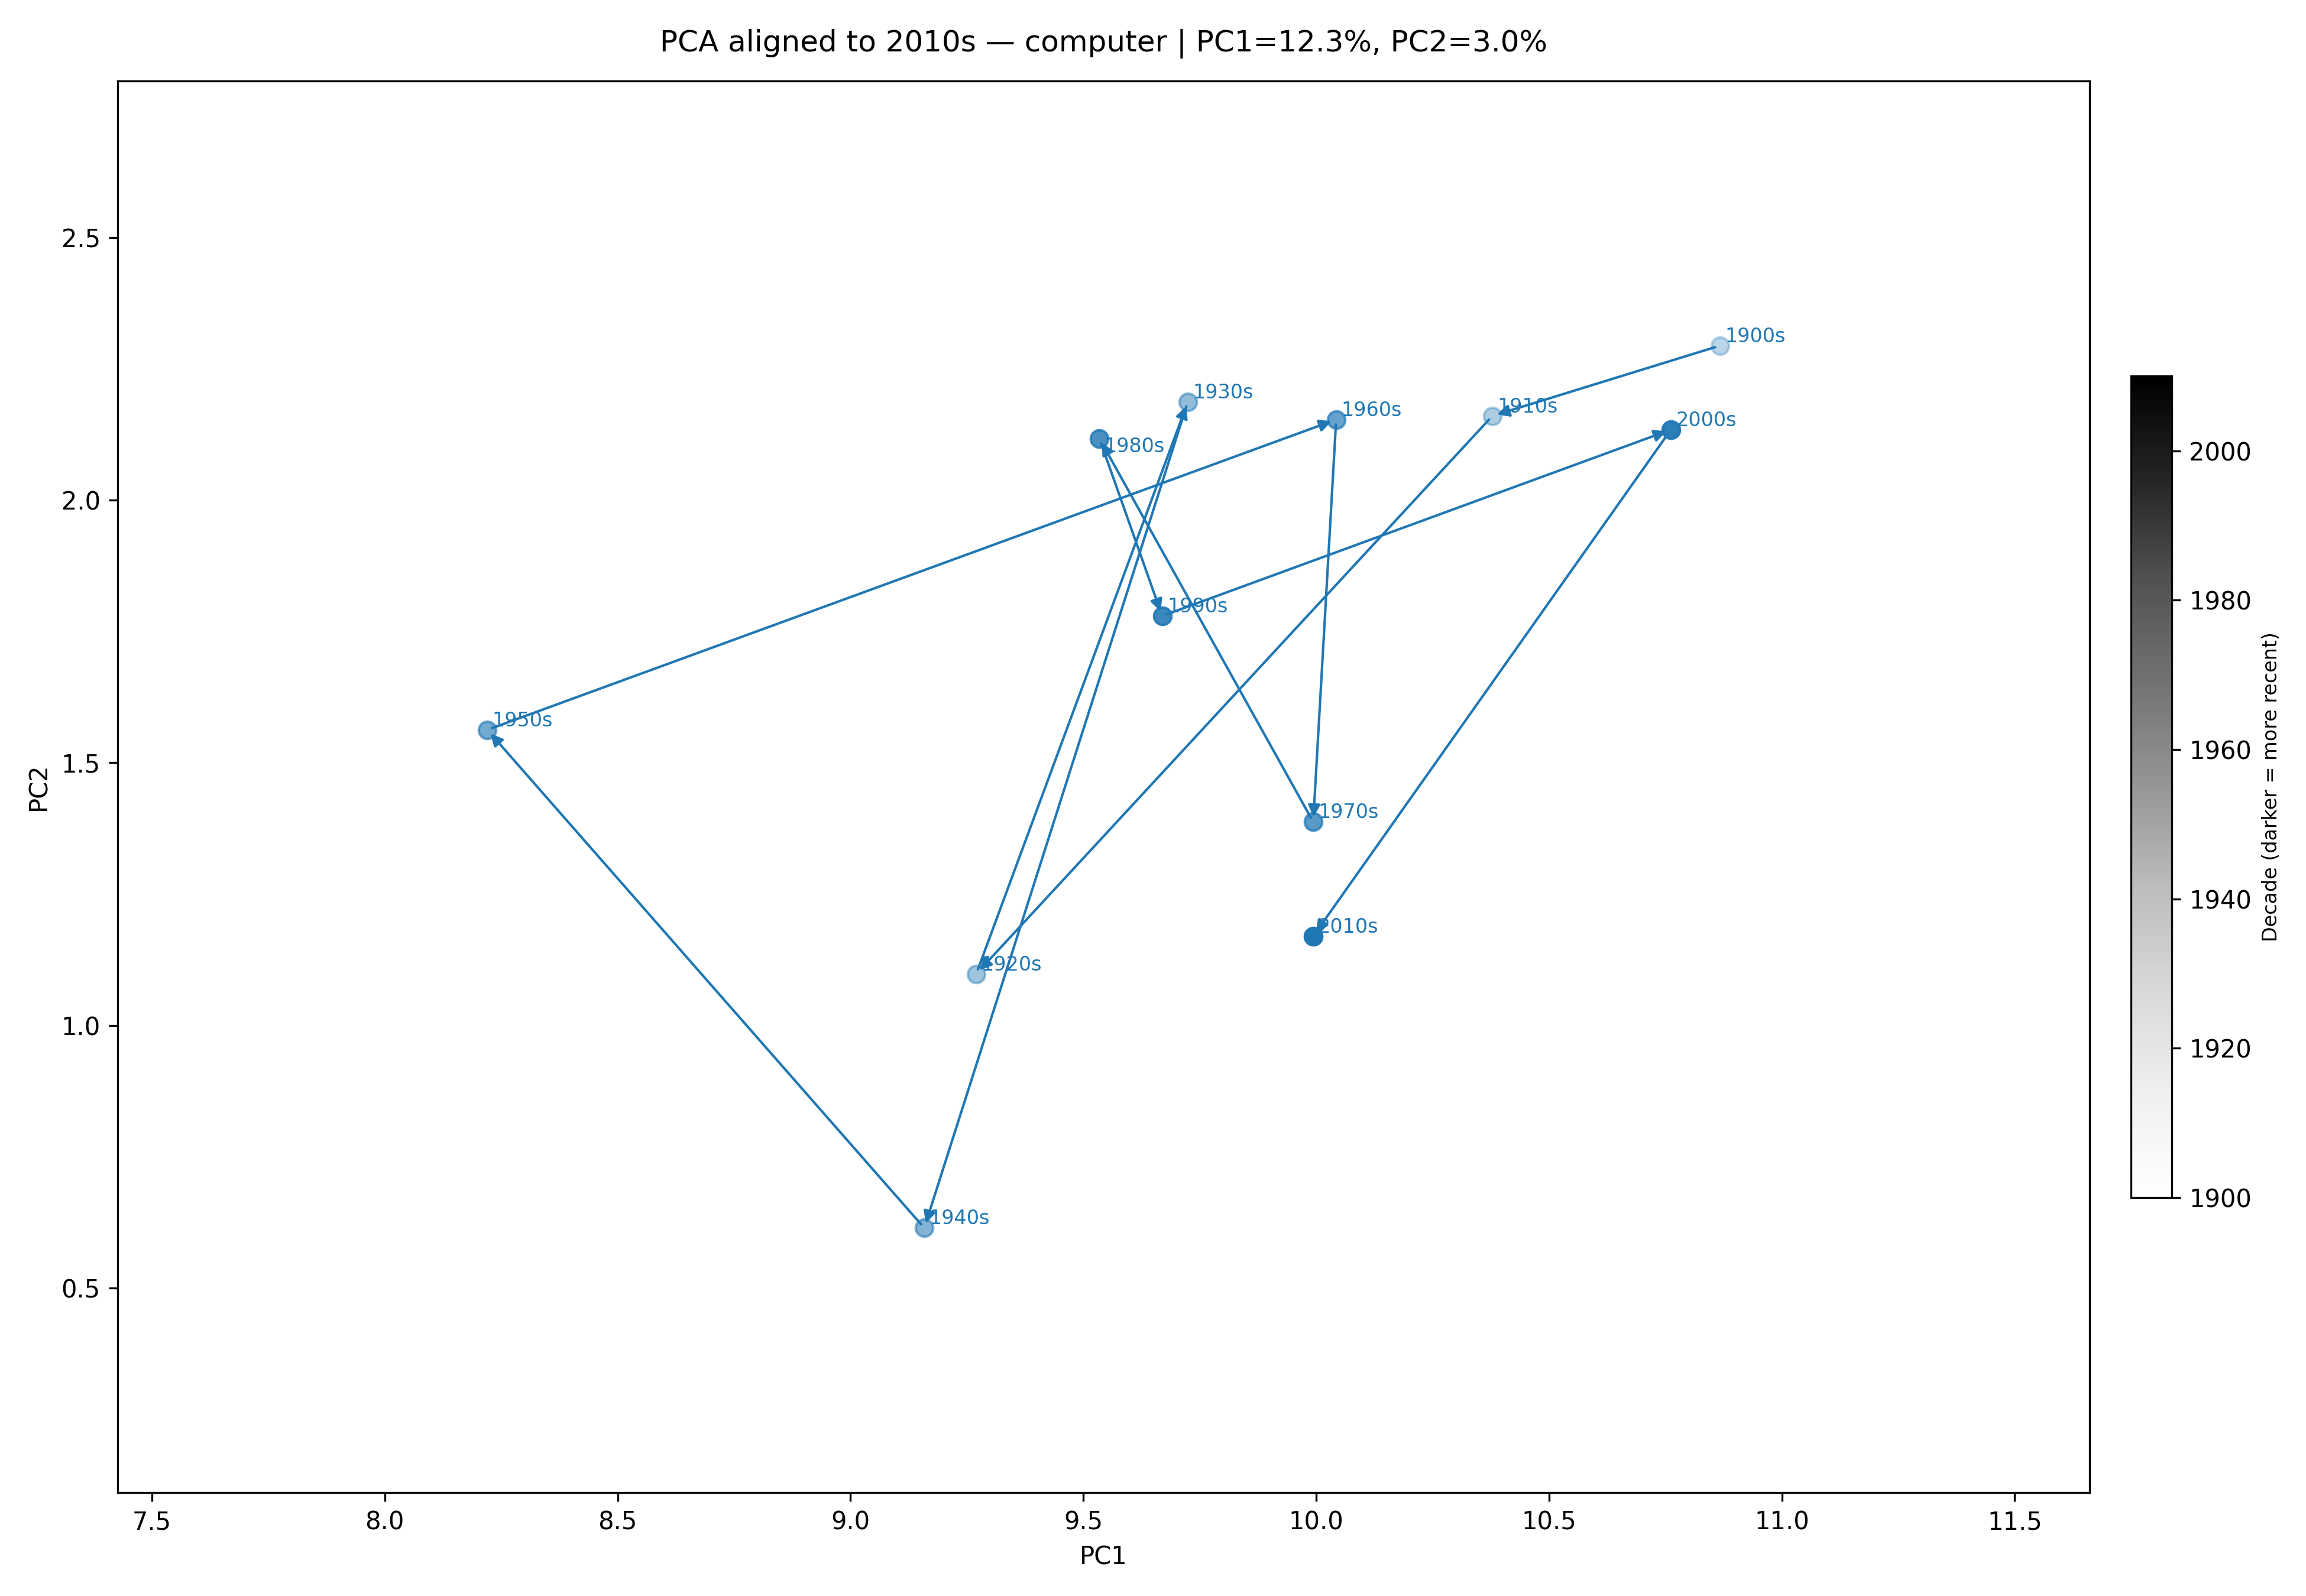

/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/pca_internet_ref_2010s_win_ALL_ALL.png


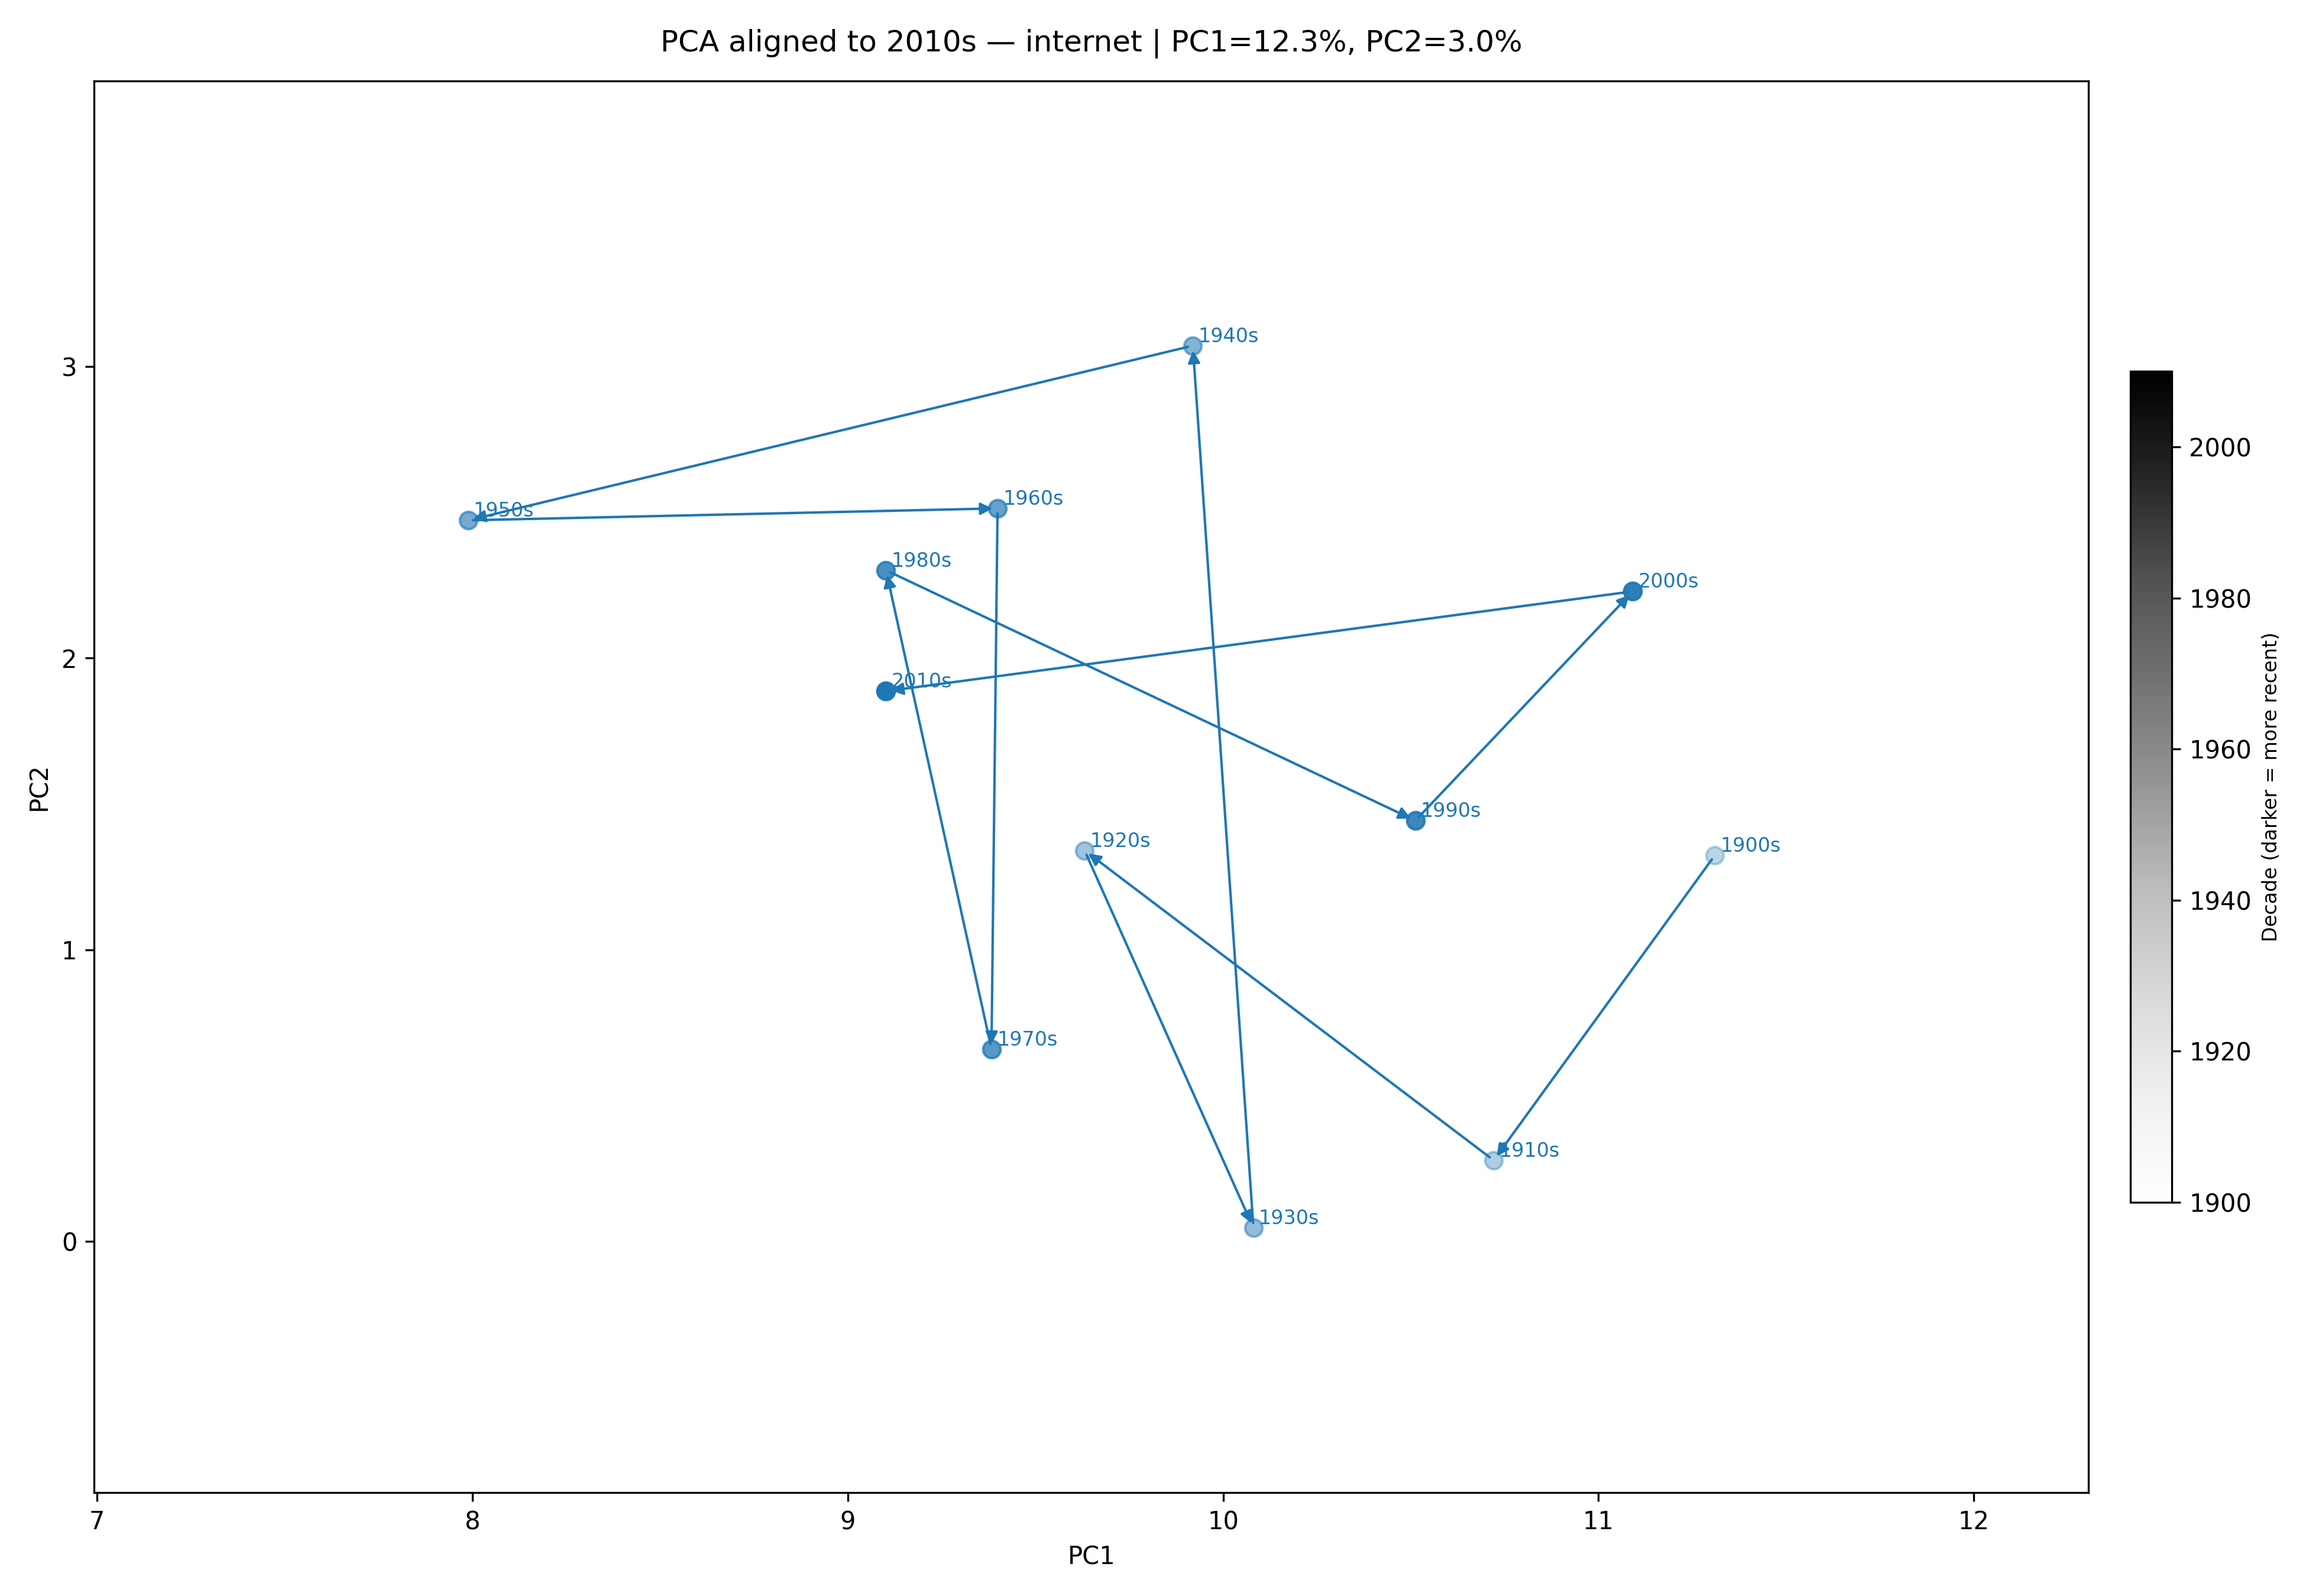

/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/pca_cloud_ref_2010s_win_ALL_ALL.png


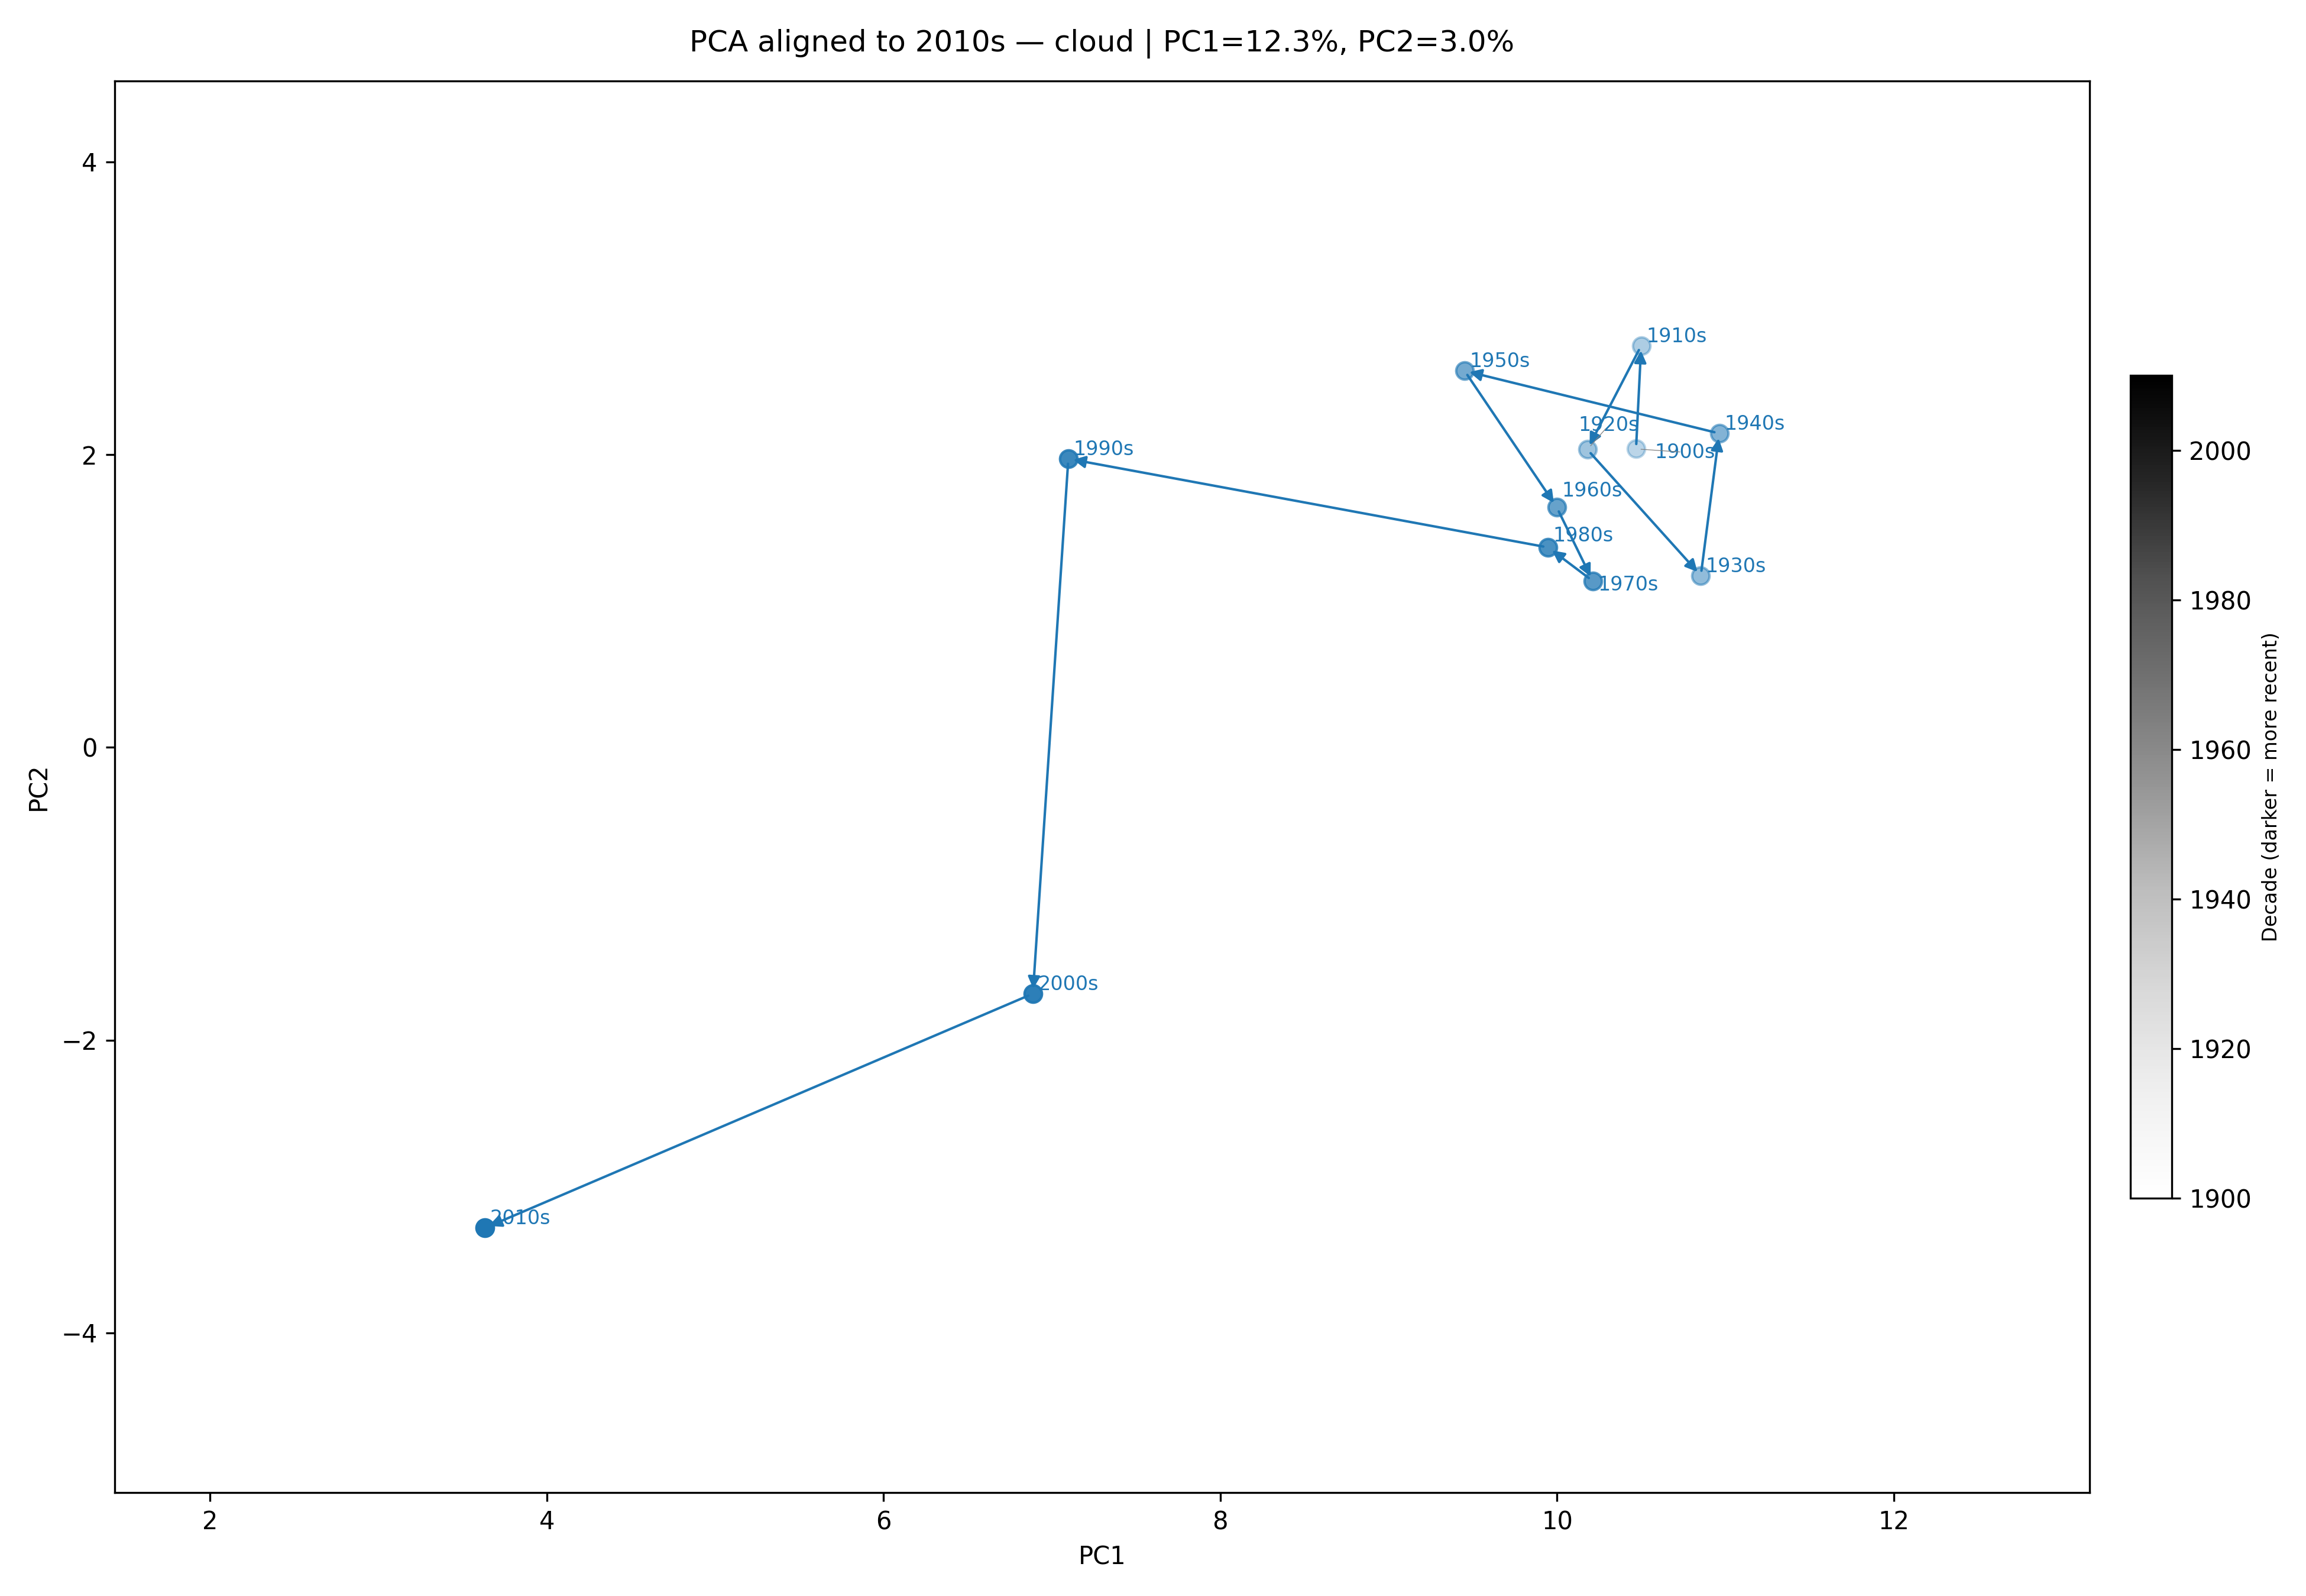

In [31]:
if RUN_PCA:
    if X_bg is not None and len(X_bg) > 0:
        pca    = PCA(n_components=2, random_state=SEED)
        pca.fit(X_bg)
        X2_pca = pca.transform(X_traj)
    else:
        pca    = PCA(n_components=2, random_state=SEED)
        X2_pca = pca.fit_transform(X_traj)

    ev = pca.explained_variance_ratio_
    print(f"Explained variance: PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%  total={sum(ev)*100:.1f}%")

    out_pca = PLOTS_DIR / f"pca_{'_'.join(TARGET_WORDS)}_ref_{REFERENCE_DECADE}_win_ALL_ALL.png"

    plot_trajectory(
        X2      = X2_pca,
        words   = TARGET_WORDS,
        title   = f"PCA aligned to {REFERENCE_DECADE} | PC1={ev[0]*100:.1f}%, PC2={ev[1]*100:.1f}%",
        out_path= out_pca,
        connect = CONNECT,
        xlabel  = "PC1",
        ylabel  = "PC2",
    )

    from IPython.display import Image, display
    display(Image(str(out_pca)))

    # Per-word single plots
    if PCA_SINGLE_WORD:
        for w in TARGET_WORDS:
            wi       = TARGET_WORDS.index(w)
            n_dec    = len(DECADES)
            idxs_w   = [wi * n_dec + di for di in range(n_dec)]
            X_traj_w = X_traj[idxs_w]
            X2_w     = pca.transform(X_traj_w)

            out_pca_w = PLOTS_DIR / f"pca_{w}_ref_{REFERENCE_DECADE}_win_ALL_ALL.png"
            plot_trajectory(
                X2      = X2_w,
                words   = [w],
                title   = f"PCA aligned to {REFERENCE_DECADE} — {w} | PC1={ev[0]*100:.1f}%, PC2={ev[1]*100:.1f}%",
                out_path= out_pca_w,
                connect = CONNECT,
                xlabel  = "PC1",
                ylabel  = "PC2",
            )
            display(Image(str(out_pca_w)))
else:
    print("RUN_PCA=False — skipping.")

## Stage 9 — t-SNE Projection and Plot (`visualize_drift.py` + `plotting.py`)

t-SNE is a non-linear dimensionality reduction method that **preserves local neighbourhood structure** rather than global variance. Points that were close neighbours in the 300-dimensional aligned space tend to remain close in the 2D layout. This makes t-SNE complementary to PCA: it is better at revealing semantic clusters but the distances between clusters carry no metric meaning and should not be compared across runs.

**Fit on background + trajectory, plot trajectory only.** When `X_bg` is available, the background is prepended to the trajectory matrix before calling `fit_transform`. The total input to t-SNE is `(BACKGROUND_N + len(TARGET_WORDS) * len(DECADES), 300)`. After the 2D embedding is computed, only the rows from index `offset` onward (the trajectory rows) are extracted and passed to `plot_trajectory`. The background points are discarded — they were only used to give t-SNE sufficient neighbourhood density to produce a stable, meaningful layout for the trajectory points.

**Perplexity auto-computation.** When `PERPLEXITY=None`, the perplexity is computed as `min(30, max(2, (n_total - 1) // 3))` where `n_total` is the full input size (background + trajectory). This ensures the value is always strictly less than `n_total`, which is a hard constraint in scikit-learn's TSNE implementation.

**Reproducibility.** `init="random"` and `random_state=SEED` are set explicitly. t-SNE is sensitive to initialisation; fixing the seed ensures the same layout is produced on every run with the same data and parameters.

**Output filename** follows the convention: `tsne_<words>_ref_<ref_decade>_perp_<perp>.png`.

When `TSNE_SINGLE_WORD=True`, after the multi-word plot, t-SNE is recomputed independently for each word individually using the same background. The output is named `tsne_<word>_ref_<ref_decade>_perp_<perp>.png`.

t-SNE: n_total=1536  (background=1500, trajectory=36)  perplexity=30


/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/tsne_computer_internet_cloud_ref_2010s_perp_30.png


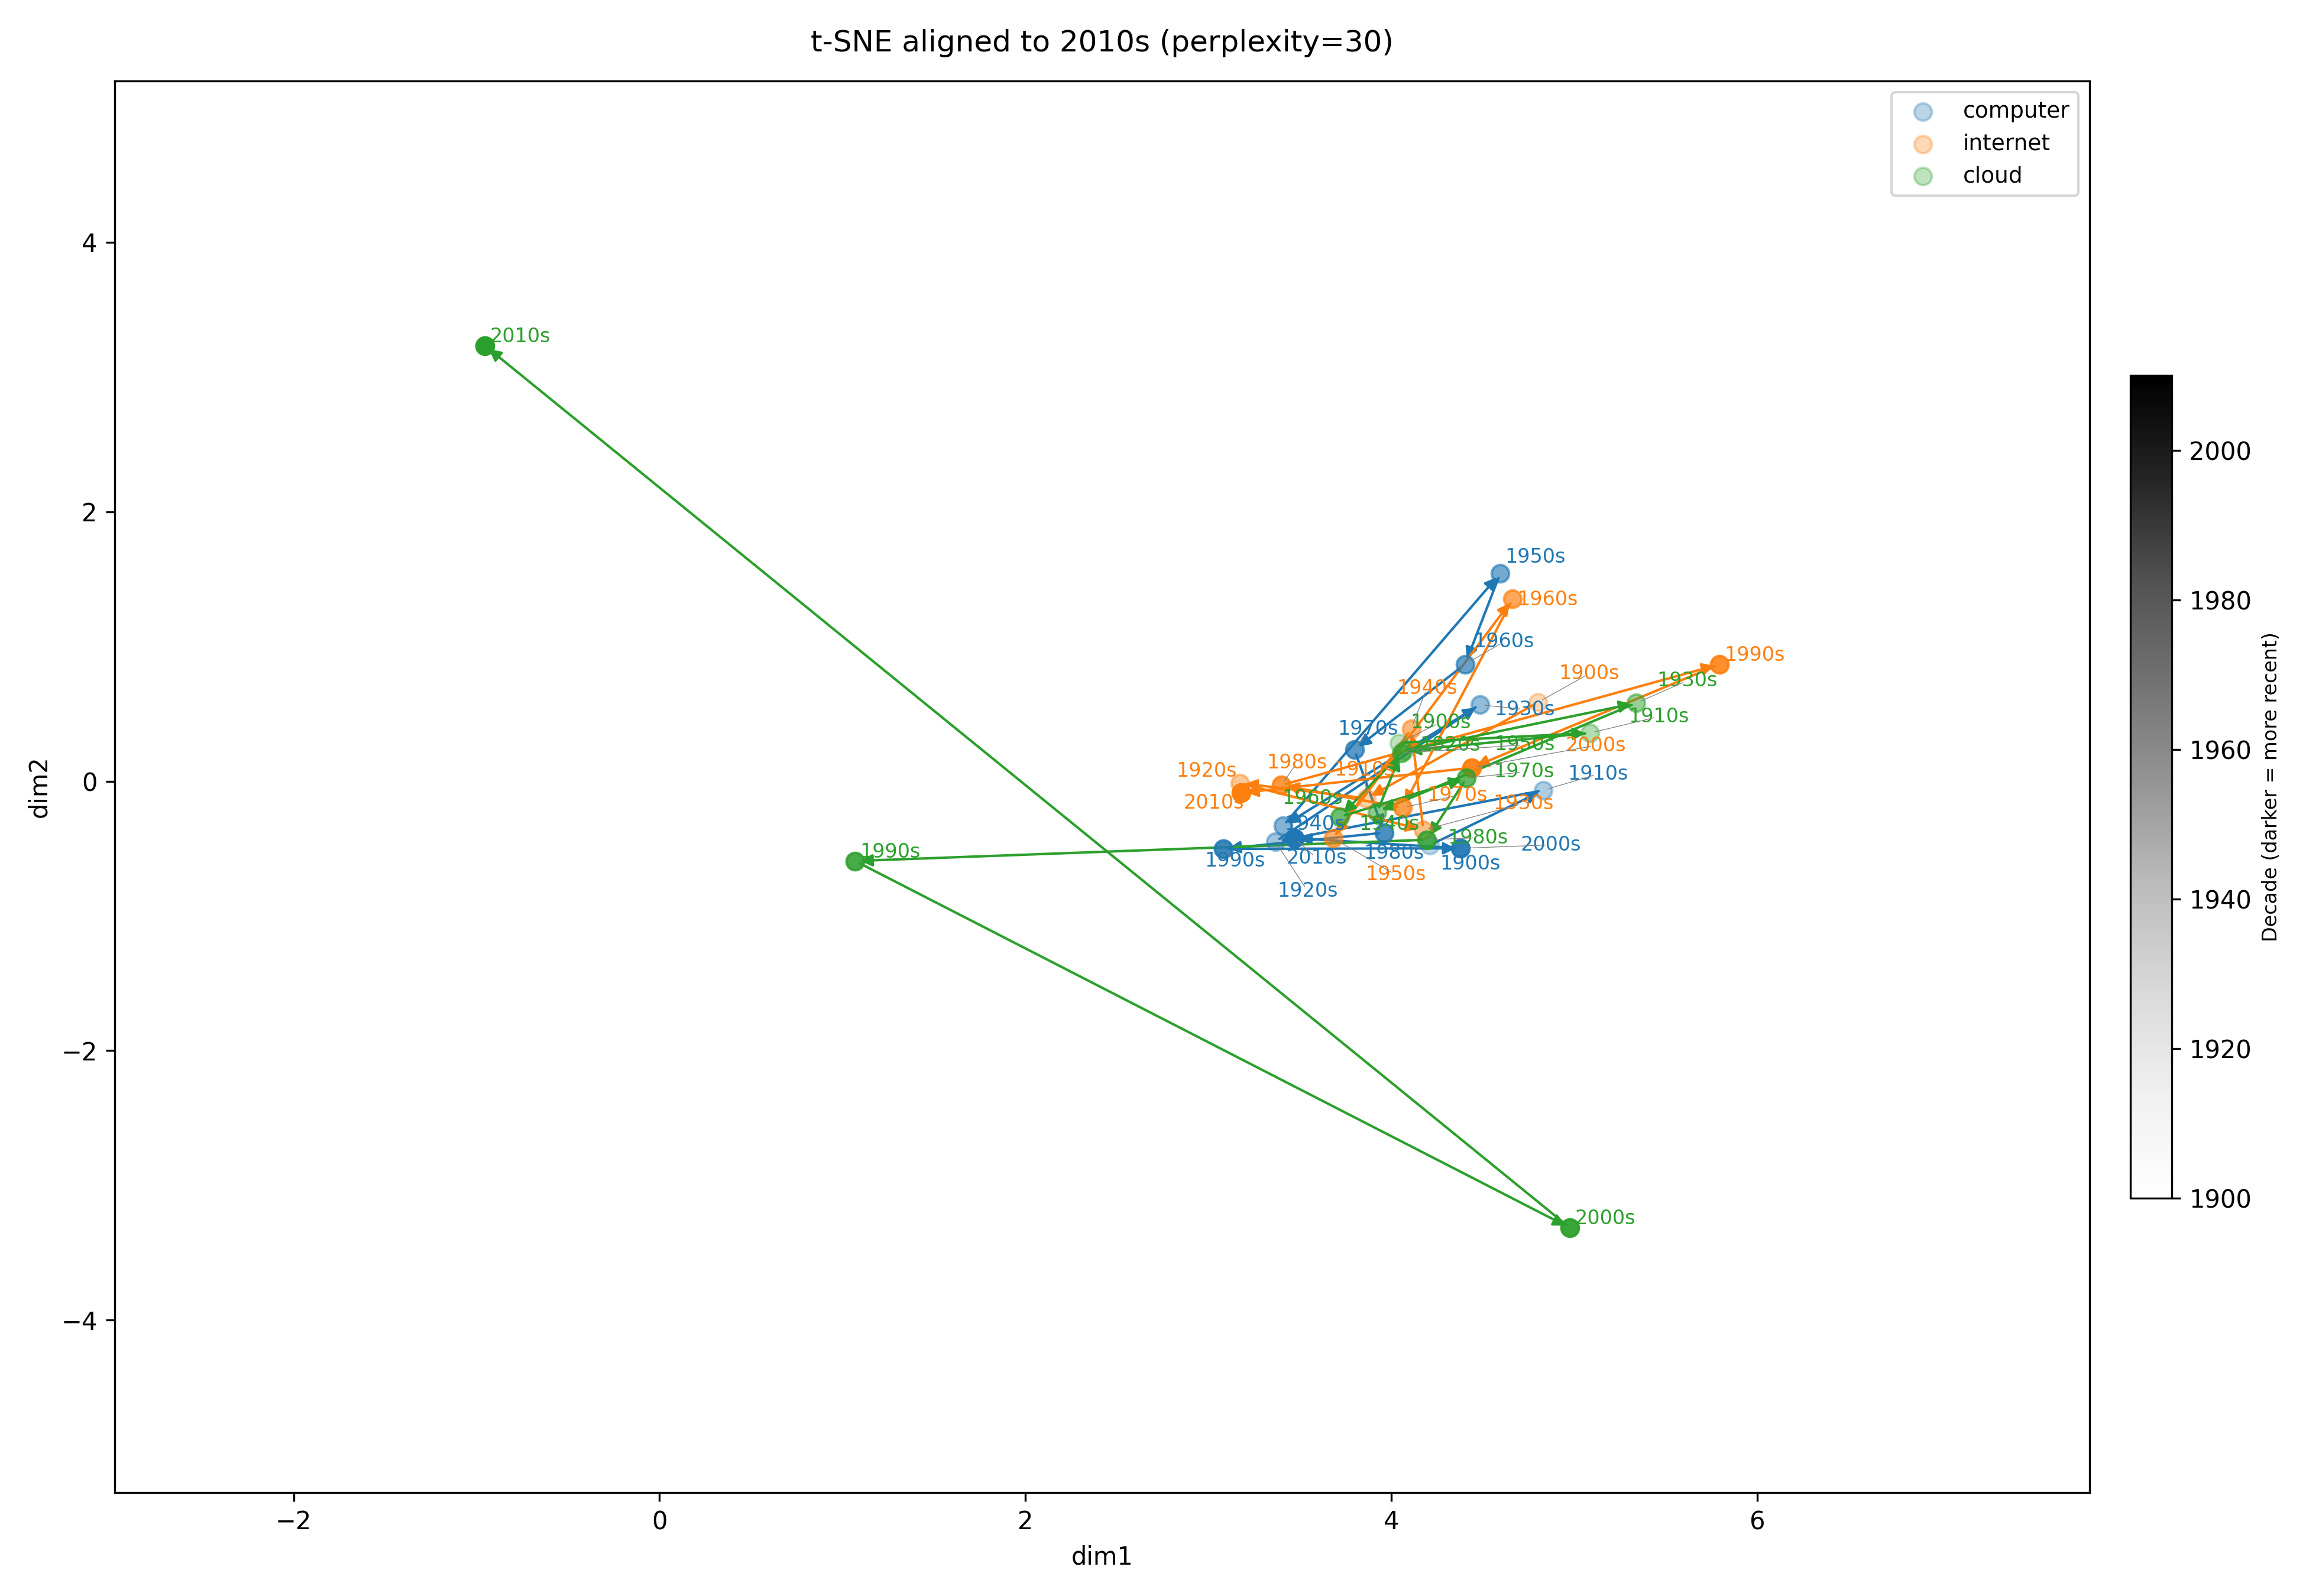

/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/tsne_computer_ref_2010s_perp_30.png


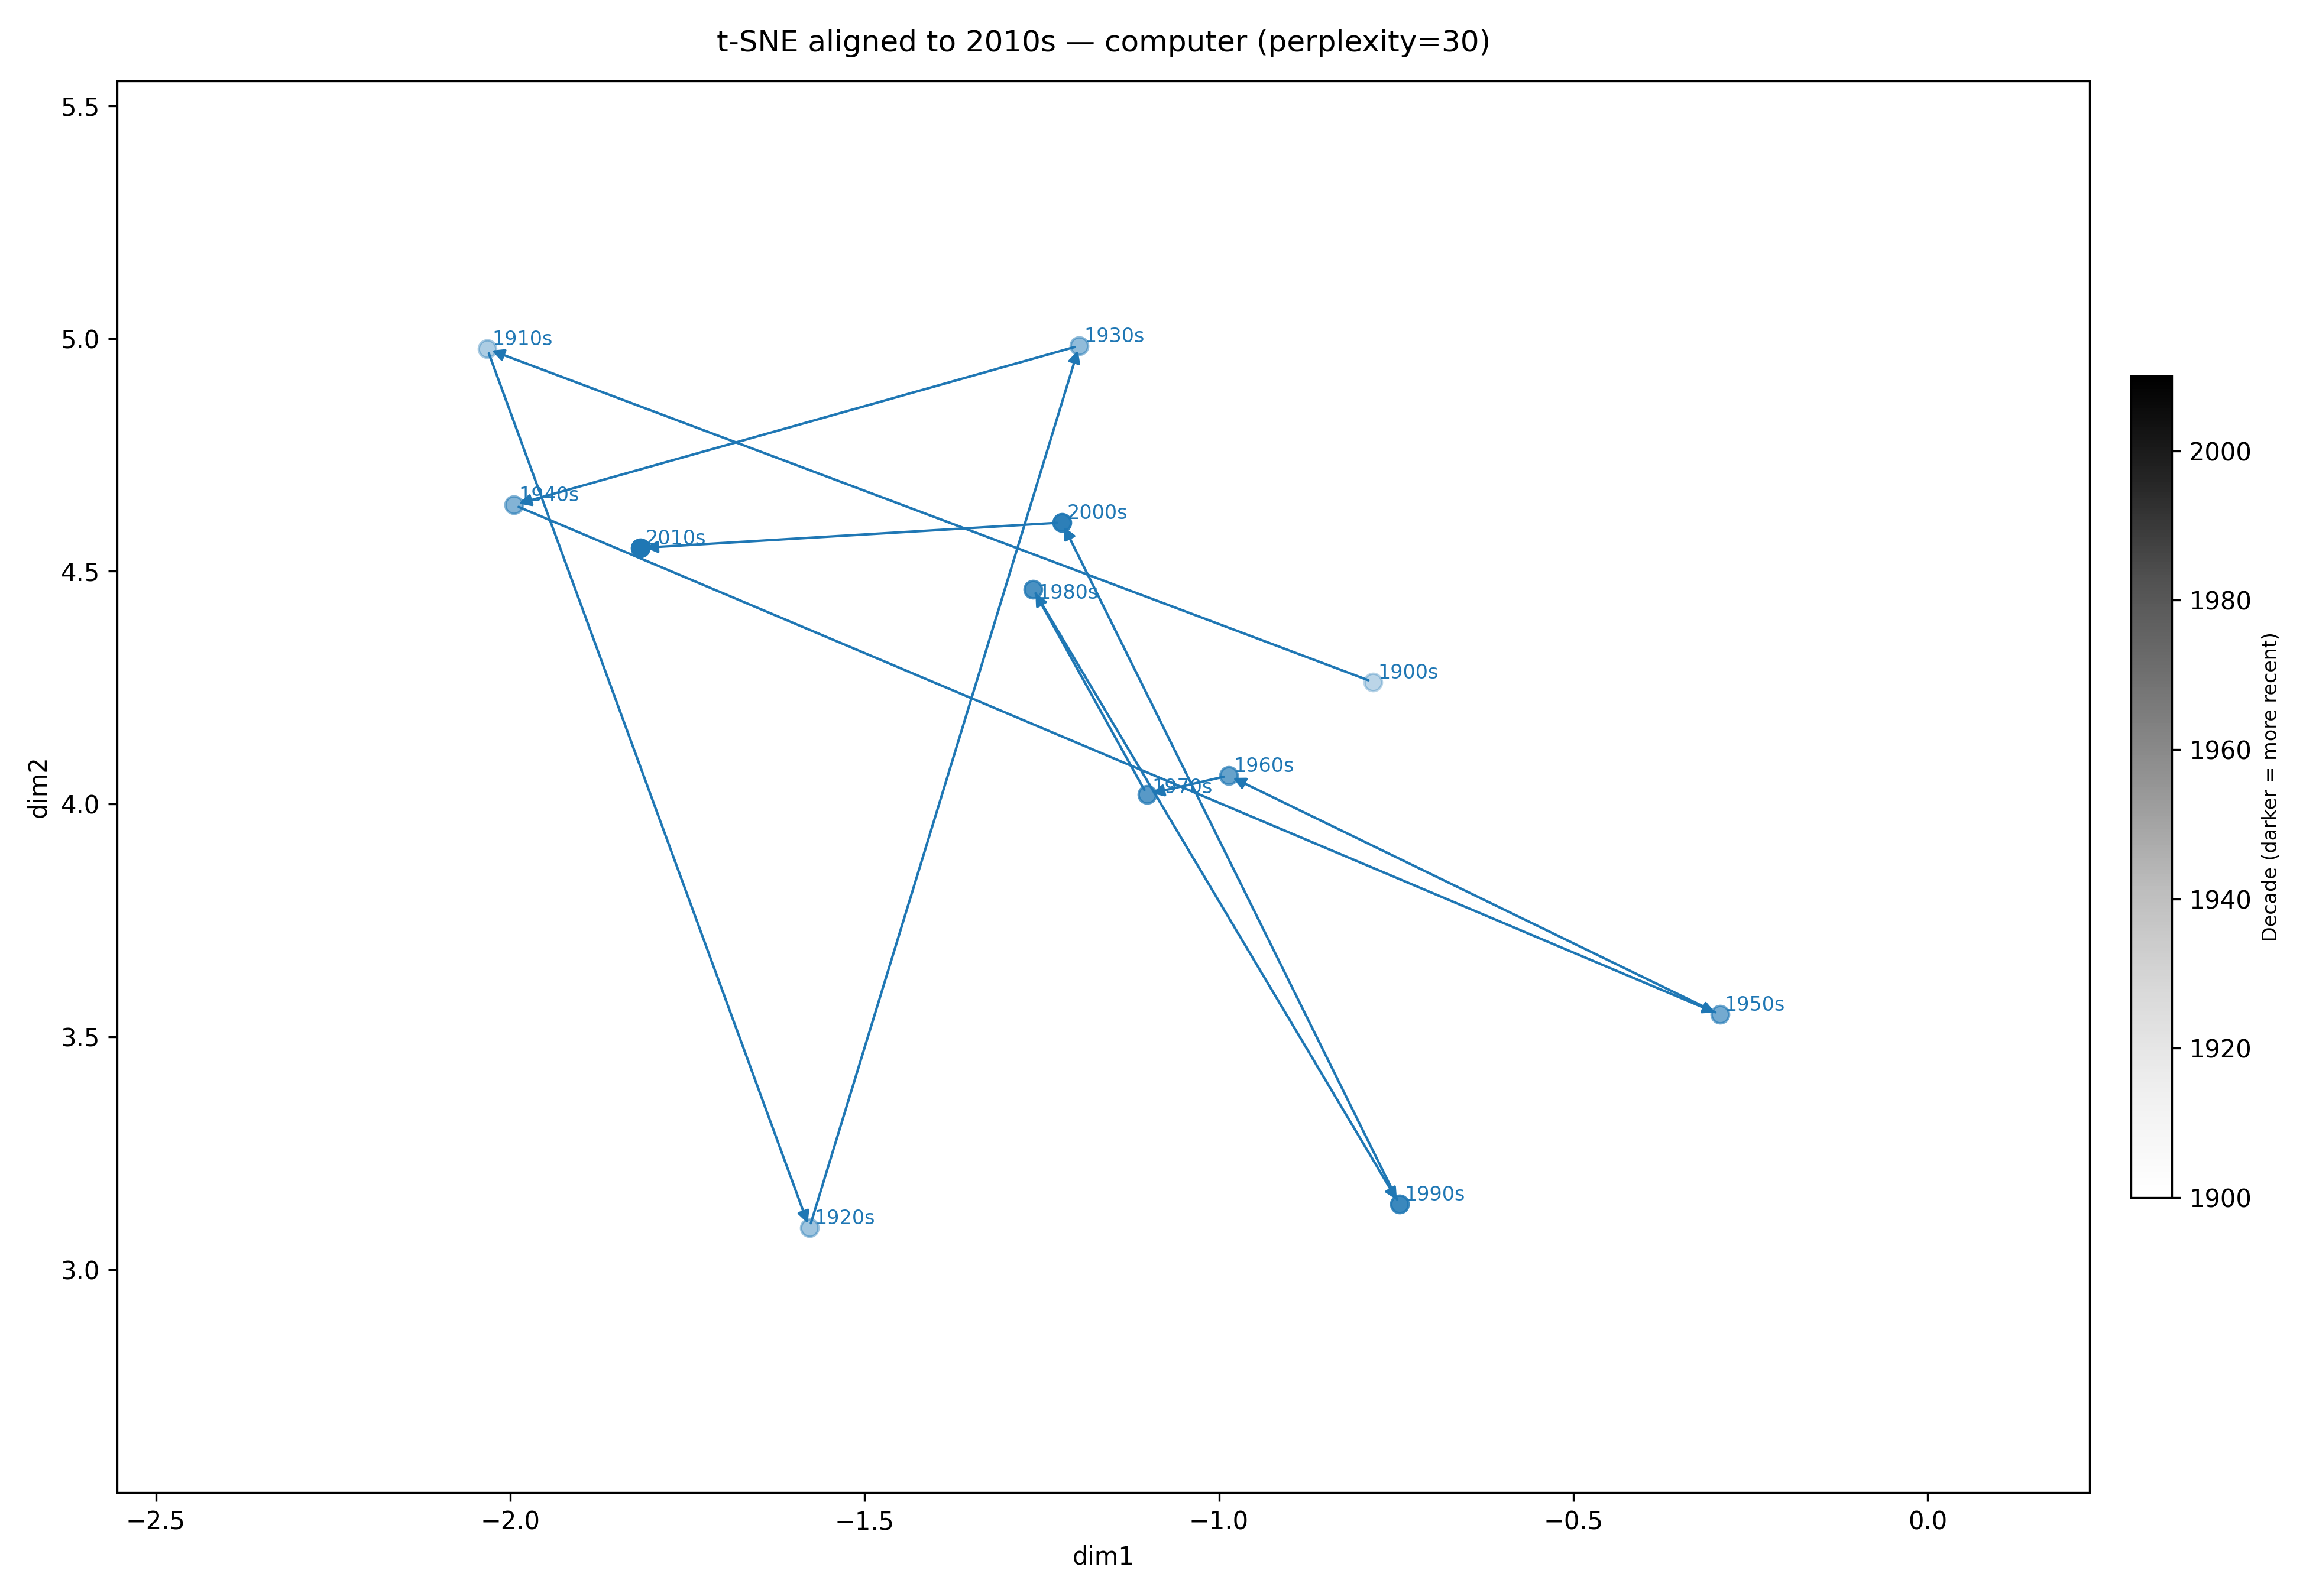

/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/tsne_internet_ref_2010s_perp_30.png


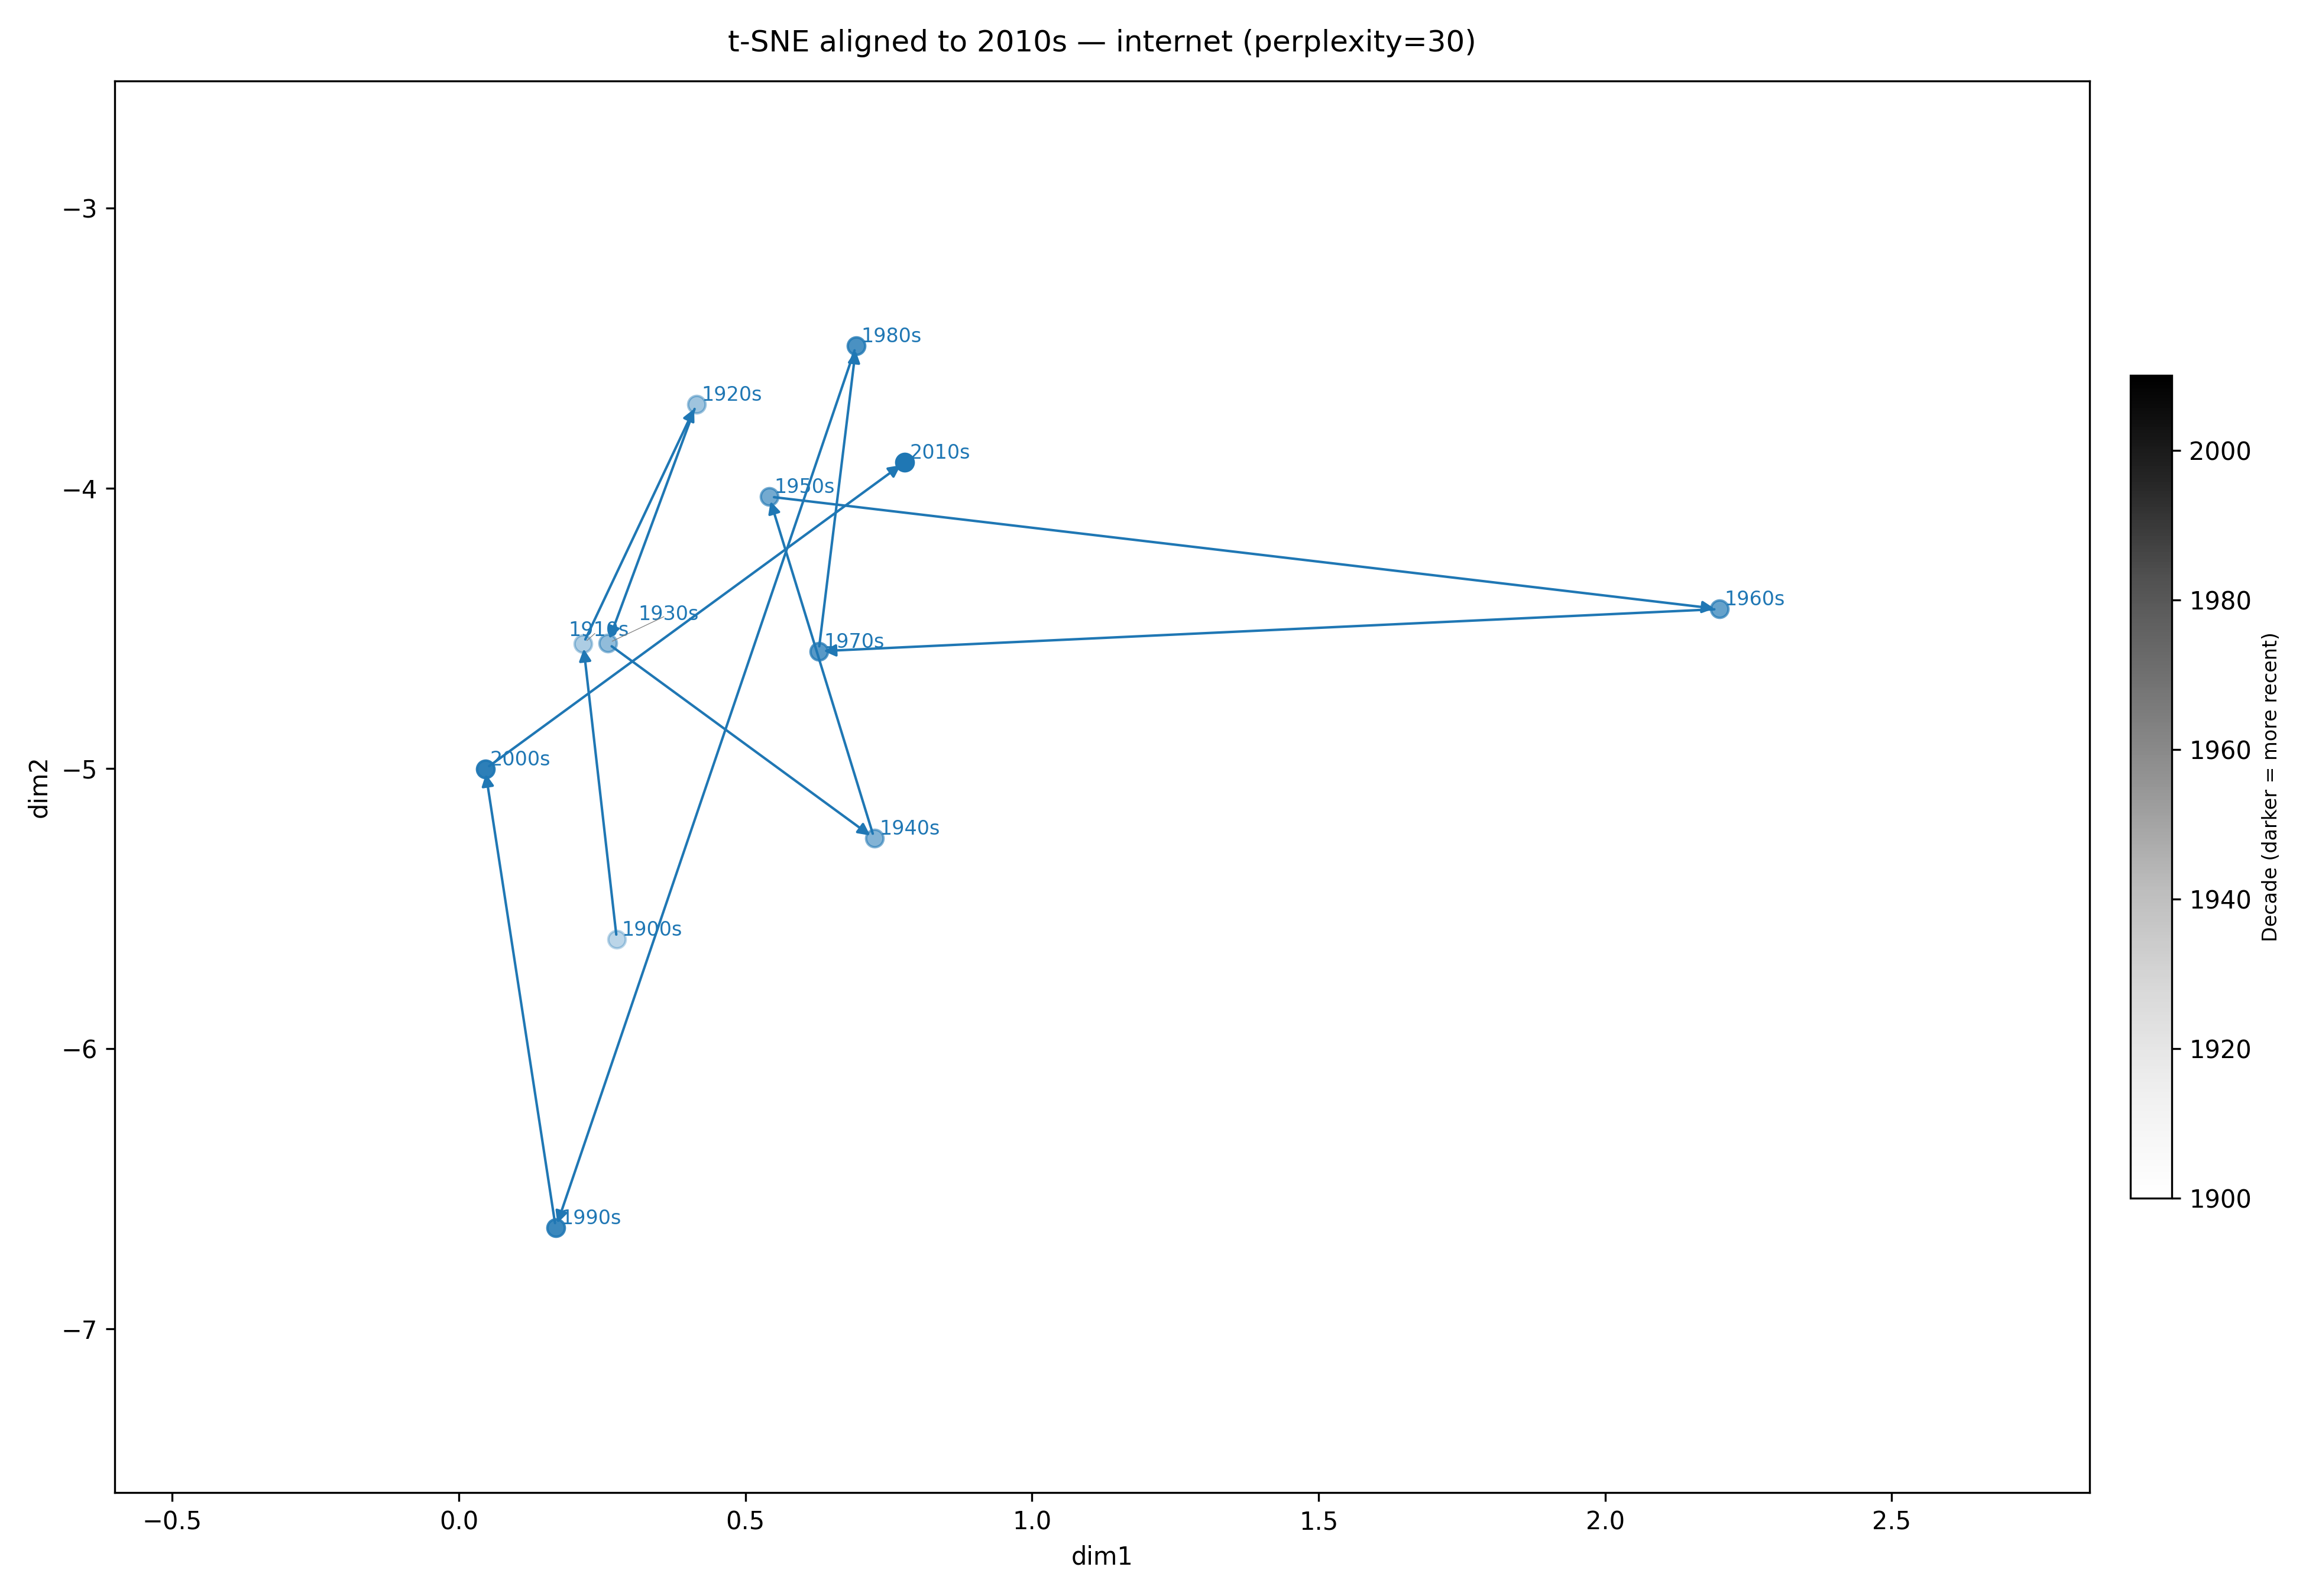

/tmp/ipykernel_1843470/2997131902.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab10")


Plot saved → /home/sperrotta/diachronic_text_analysis/plots/tsne_cloud_ref_2010s_perp_30.png


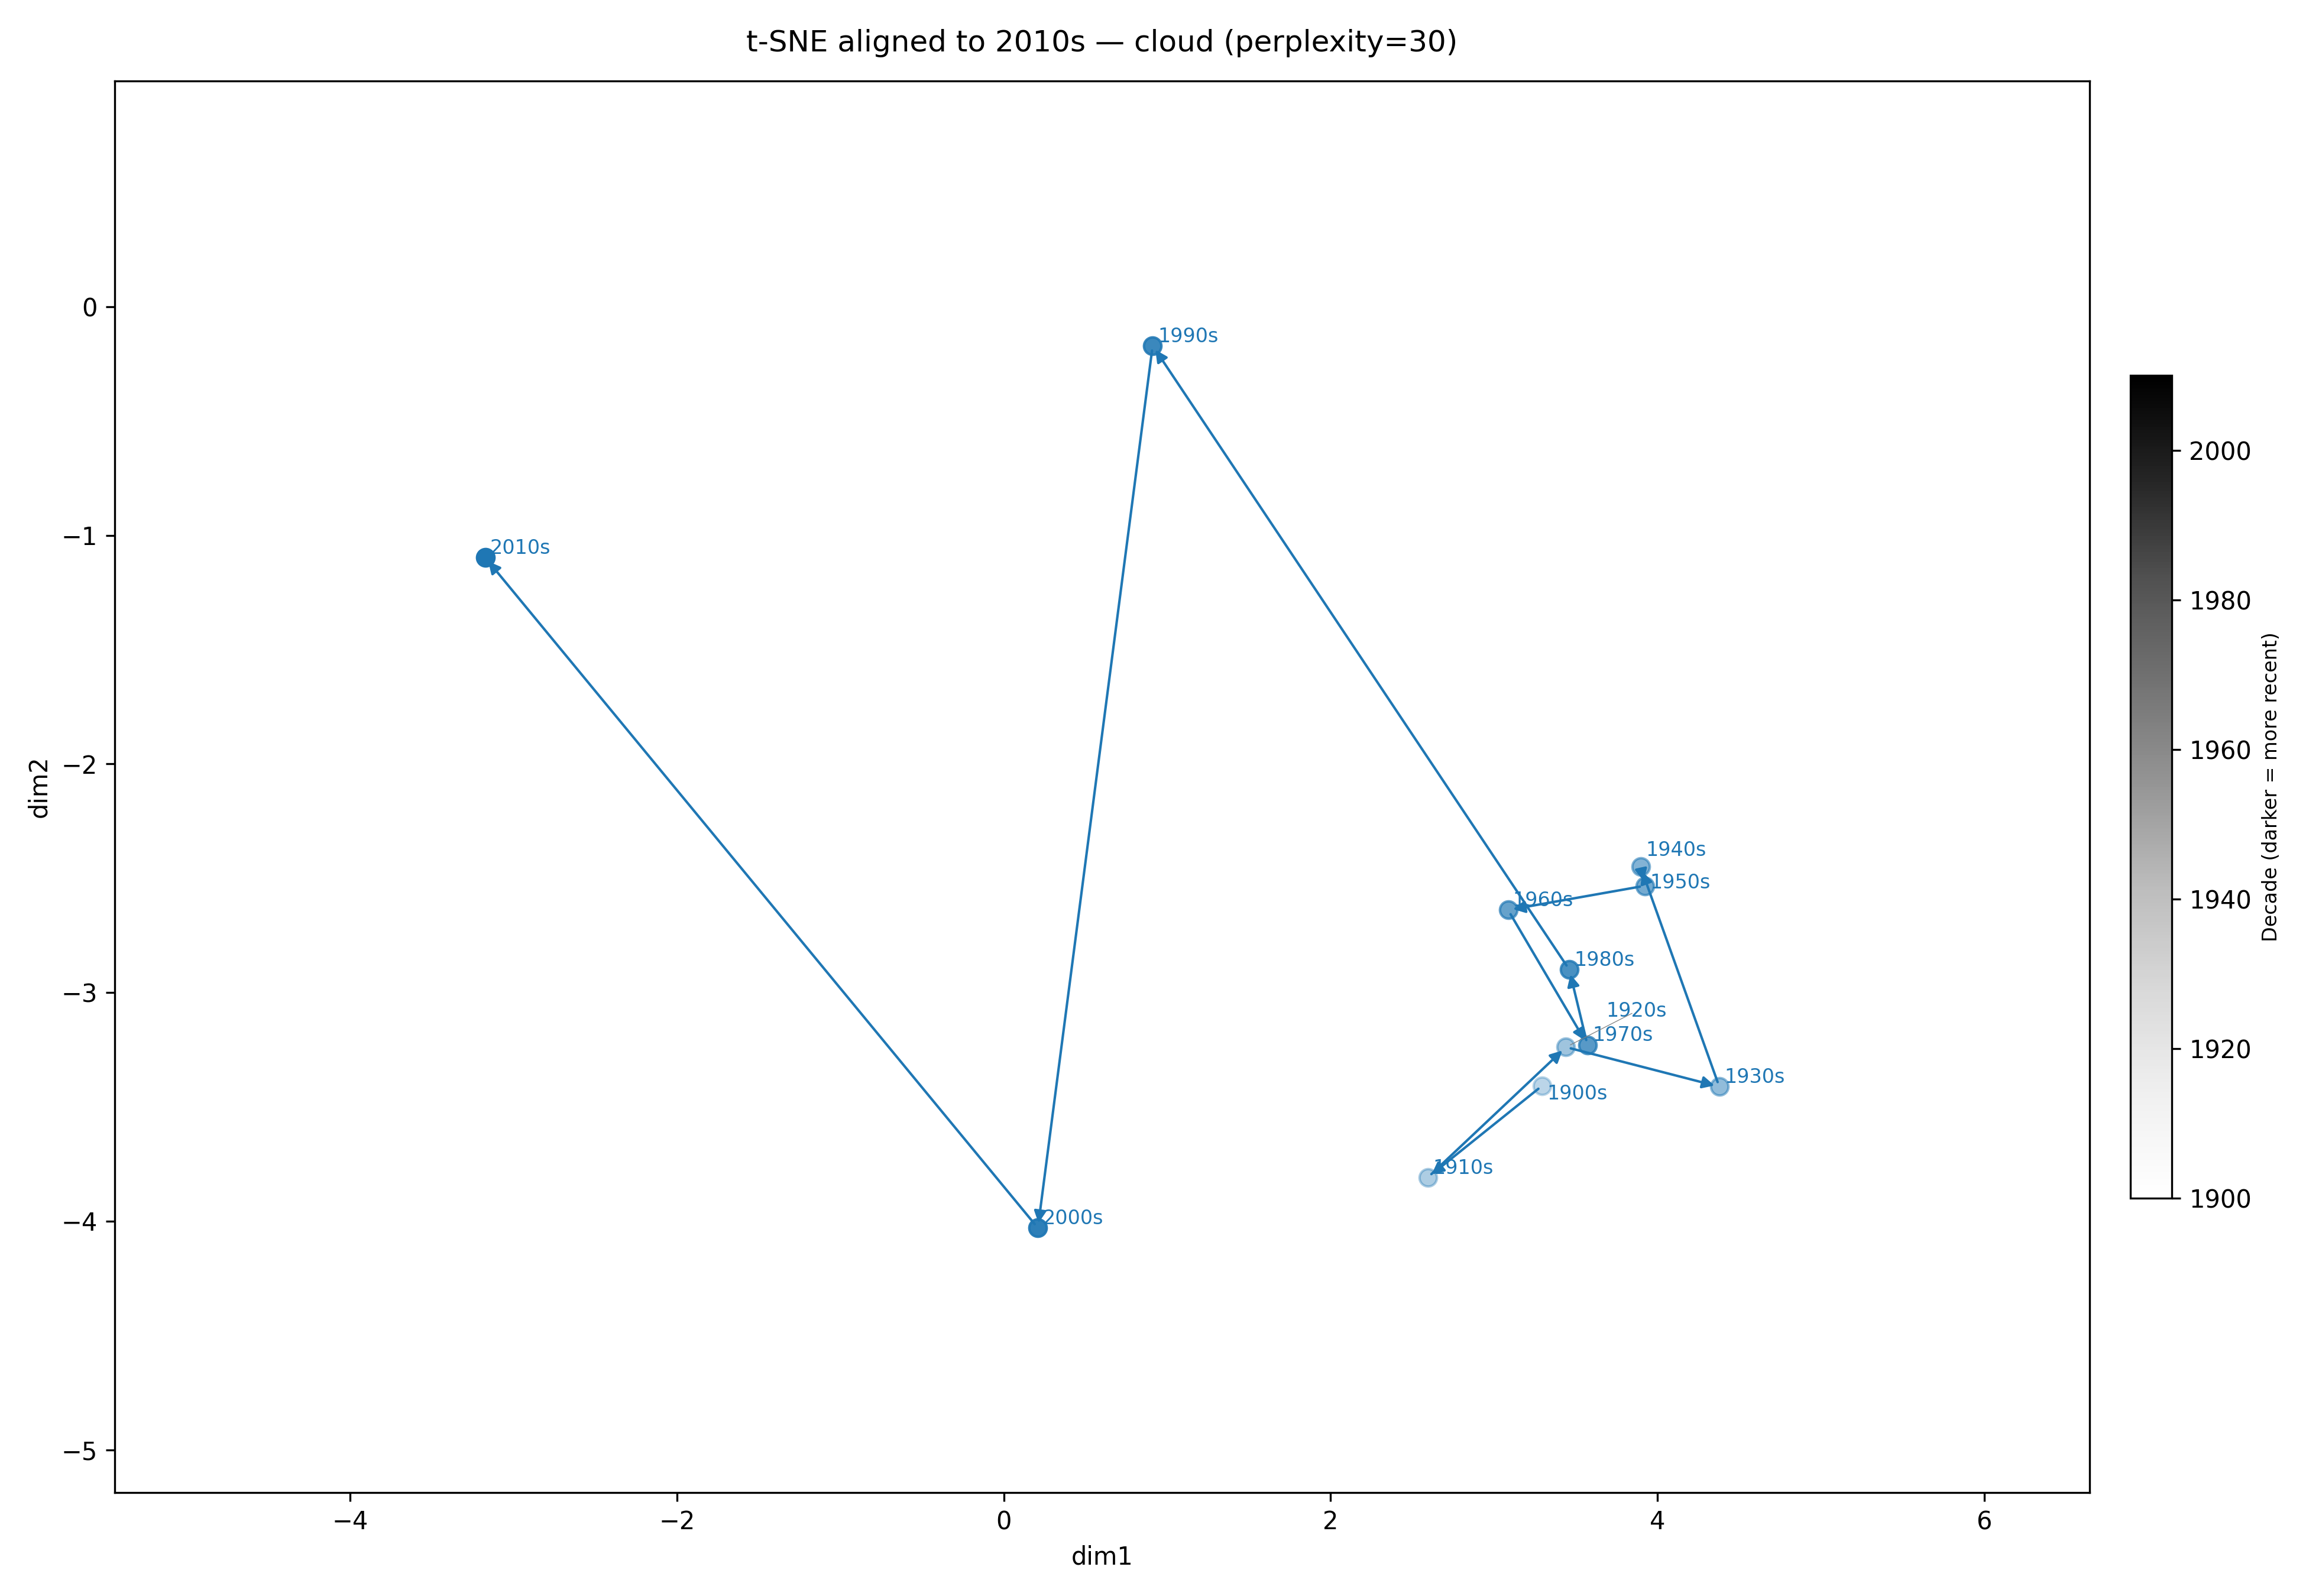

In [32]:
if RUN_TSNE:
    if X_bg is not None and len(X_bg) > 0:
        X_for_tsne = np.vstack([X_bg, X_traj])
        offset     = len(X_bg)
    else:
        X_for_tsne = X_traj
        offset     = 0

    n    = X_for_tsne.shape[0]
    perp = min(30, max(2, (n - 1) // 3)) if PERPLEXITY is None else PERPLEXITY

    if perp >= n:
        raise ValueError(f"perplexity ({perp}) must be < n_samples ({n})")

    print(f"t-SNE: n_total={n}  (background={offset}, trajectory={n - offset})  perplexity={perp}")

    tsne = TSNE(n_components=2, init="random", learning_rate="auto",
                random_state=SEED, perplexity=perp)
    X2_all  = tsne.fit_transform(X_for_tsne)
    X2_traj = X2_all[offset:, :]

    out_tsne = PLOTS_DIR / f"tsne_{'_'.join(TARGET_WORDS)}_ref_{REFERENCE_DECADE}_perp_{perp}.png"

    plot_trajectory(
        X2      = X2_traj,
        words   = TARGET_WORDS,
        title   = f"t-SNE aligned to {REFERENCE_DECADE} (perplexity={perp})",
        out_path= out_tsne,
        connect = CONNECT,
        xlabel  = "dim1",
        ylabel  = "dim2",
    )

    from IPython.display import Image, display
    display(Image(str(out_tsne)))

    # Per-word single plots
    if TSNE_SINGLE_WORD:
        for w in TARGET_WORDS:
            wi          = TARGET_WORDS.index(w)
            n_dec       = len(DECADES)
            idxs_w      = [wi * n_dec + di for di in range(n_dec)]
            X_traj_w    = X_traj[idxs_w]

            if X_bg is not None and len(X_bg) > 0:
                X_for_tsne_w = np.vstack([X_bg, X_traj_w])
                offset_w     = len(X_bg)
            else:
                X_for_tsne_w = X_traj_w
                offset_w     = 0

            n_w    = X_for_tsne_w.shape[0]
            perp_w = min(30, max(2, (n_w - 1) // 3)) if PERPLEXITY is None else PERPLEXITY
            perp_w = min(perp_w, n_w - 1)

            tsne_w   = TSNE(n_components=2, init="random", learning_rate="auto",
                            random_state=SEED, perplexity=perp_w)
            X2_all_w = tsne_w.fit_transform(X_for_tsne_w)
            X2_w     = X2_all_w[offset_w:, :]

            out_tsne_w = PLOTS_DIR / f"tsne_{w}_ref_{REFERENCE_DECADE}_perp_{perp_w}.png"
            plot_trajectory(
                X2      = X2_w,
                words   = [w],
                title   = f"t-SNE aligned to {REFERENCE_DECADE} — {w} (perplexity={perp_w})",
                out_path= out_tsne_w,
                connect = CONNECT,
                xlabel  = "dim1",
                ylabel  = "dim2",
            )
            display(Image(str(out_tsne_w)))
else:
    print("RUN_TSNE=False — skipping.")

## Stage 10 — Diachronic Associations Plot (`diachronic_associations.py`)

This stage produces a different type of visualisation that shows, for a **single target word**, how its nearest neighbors and their cosine similarity scores evolve decade by decade.

The plot layout is a scatter plot where:
- **x-axis** — decade expressed as a start year (e.g. 1940 for "1940s")
- **y-axis** — cosine similarity between the target word and each of its top-K neighbors in that decade's aligned space
- **each point** — one neighbor word, annotated with its text label

This makes semantic drift directly readable: when the neighbors of a word in the 1930s are entirely different from the neighbors in the 1990s, the word has changed meaning. When the cosine values also drop, the word's semantic neighbourhood has become less coherent or more dispersed.

### Two modes of operation

**`diachronic_associations.py` (this stage)** — recomputes neighbors directly from the aligned embeddings already in memory (`aligned_by_decade`). This is the mode used here because we have the aligned matrices available from Stage 3.

**`plot_diachronic_associations_from_results.py`** — reads neighbors from the CSVs produced in Stage 4 (`RESULTS_DIR/neighbors_<decade>.csv`) without reloading embeddings. Useful for regenerating or customising the plot without rerunning the full pipeline. It uses `adjustText` for more sophisticated label placement.

### `compute_neighbors_over_time`

Iterates over all decades in chronological order. For each decade, calls `cosine_topk` on the target word's aligned vector, excluding the word itself. Returns a flat list of row dicts with fields `word`, `decade`, `year`, `rank`, `neighbor`, `cosine`.

### `plot_diachronic_associations`

Renders the scatter plot using simple `annotate` calls. Points are not moved. If many points cluster near the same x-position (same decade), labels may overlap — use `plot_diachronic_associations_from_results.py` for better label placement via `adjustText` when this is an issue.

### Temporal windows

In addition to the full-range plot, a separate plot is produced for each `(from_decade, to_decade)` pair in `DIACHRONIC_WINDOWS`. Each window filters the rows to the specified decade range before plotting, allowing fine-grained analysis of specific periods of change.

In [34]:
DECADE_RE = re.compile(r"^(\d{4})s$")

def decade_to_year(dec: str) -> int:
    m = DECADE_RE.match(dec)
    if not m:
        raise ValueError(f"Invalid decade format: {dec!r}")
    return int(m.group(1))


def compute_neighbors_over_time(word: str, vocab: dict, inv_vocab: dict,
                                 aligned_by_decade: dict, topk: int) -> list:
    if word not in vocab:
        raise ValueError(f"Word {word!r} not in vocab.")

    rows = []
    widx = vocab[word]

    for dec in DECADES:
        E = aligned_by_decade[dec]
        top_idx, top_sims = cosine_topk(E[widx], E, k=topk, exclude_index=widx)

        for rank, (ni, sim) in enumerate(zip(top_idx, top_sims), start=1):
            rows.append({
                "word":     word,
                "decade":   dec,
                "year":     decade_to_year(dec),
                "rank":     rank,
                "neighbor": inv_vocab.get(int(ni), f"idx_{ni}"),
                "cosine":   float(sim),
            })
    return rows


def plot_diachronic_associations(rows: list, out_png: Path, title: str,
                                  min_cos: float | None = None):
    years  = np.array([r["year"]    for r in rows], dtype=float)
    cos    = np.array([r["cosine"]  for r in rows], dtype=float)
    labels = [r["neighbor"] for r in rows]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(years, cos, s=30, zorder=2)

    # Use adjustText to avoid label overlaps
    texts = [ax.text(x, y, lab, fontsize=7, zorder=3)
             for x, y, lab in zip(years, cos, labels)]

    # Expand axes before adjustText so labels have room
    x_margin = (years.max() - years.min()) * 0.05 or 5
    y_range   = cos.max() - cos.min() or 0.05
    ax.set_xlim(years.min() - x_margin, years.max() + x_margin)
    ax.set_ylim(cos.min() - 0.4 * y_range, cos.max() + 0.4 * y_range)

    if min_cos is not None:
        ax.set_ylim(bottom=min_cos)

    adjust_text(texts, ax=ax,
                expand_points=(1.3, 1.5), expand_text=(1.3, 1.5),
                arrowprops=dict(arrowstyle="-", lw=0.35, color="gray"))

    # Vertical decade separators for readability
    for yr in sorted(set(years.astype(int))):
        ax.axvline(x=yr, color="lightgray", lw=0.5, zorder=0)

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Cosine similarity to target")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=250)
    plt.close(fig)
    print(f"Diachronic associations plot saved → {out_png}")

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_computer_ref_2010s_top10.png


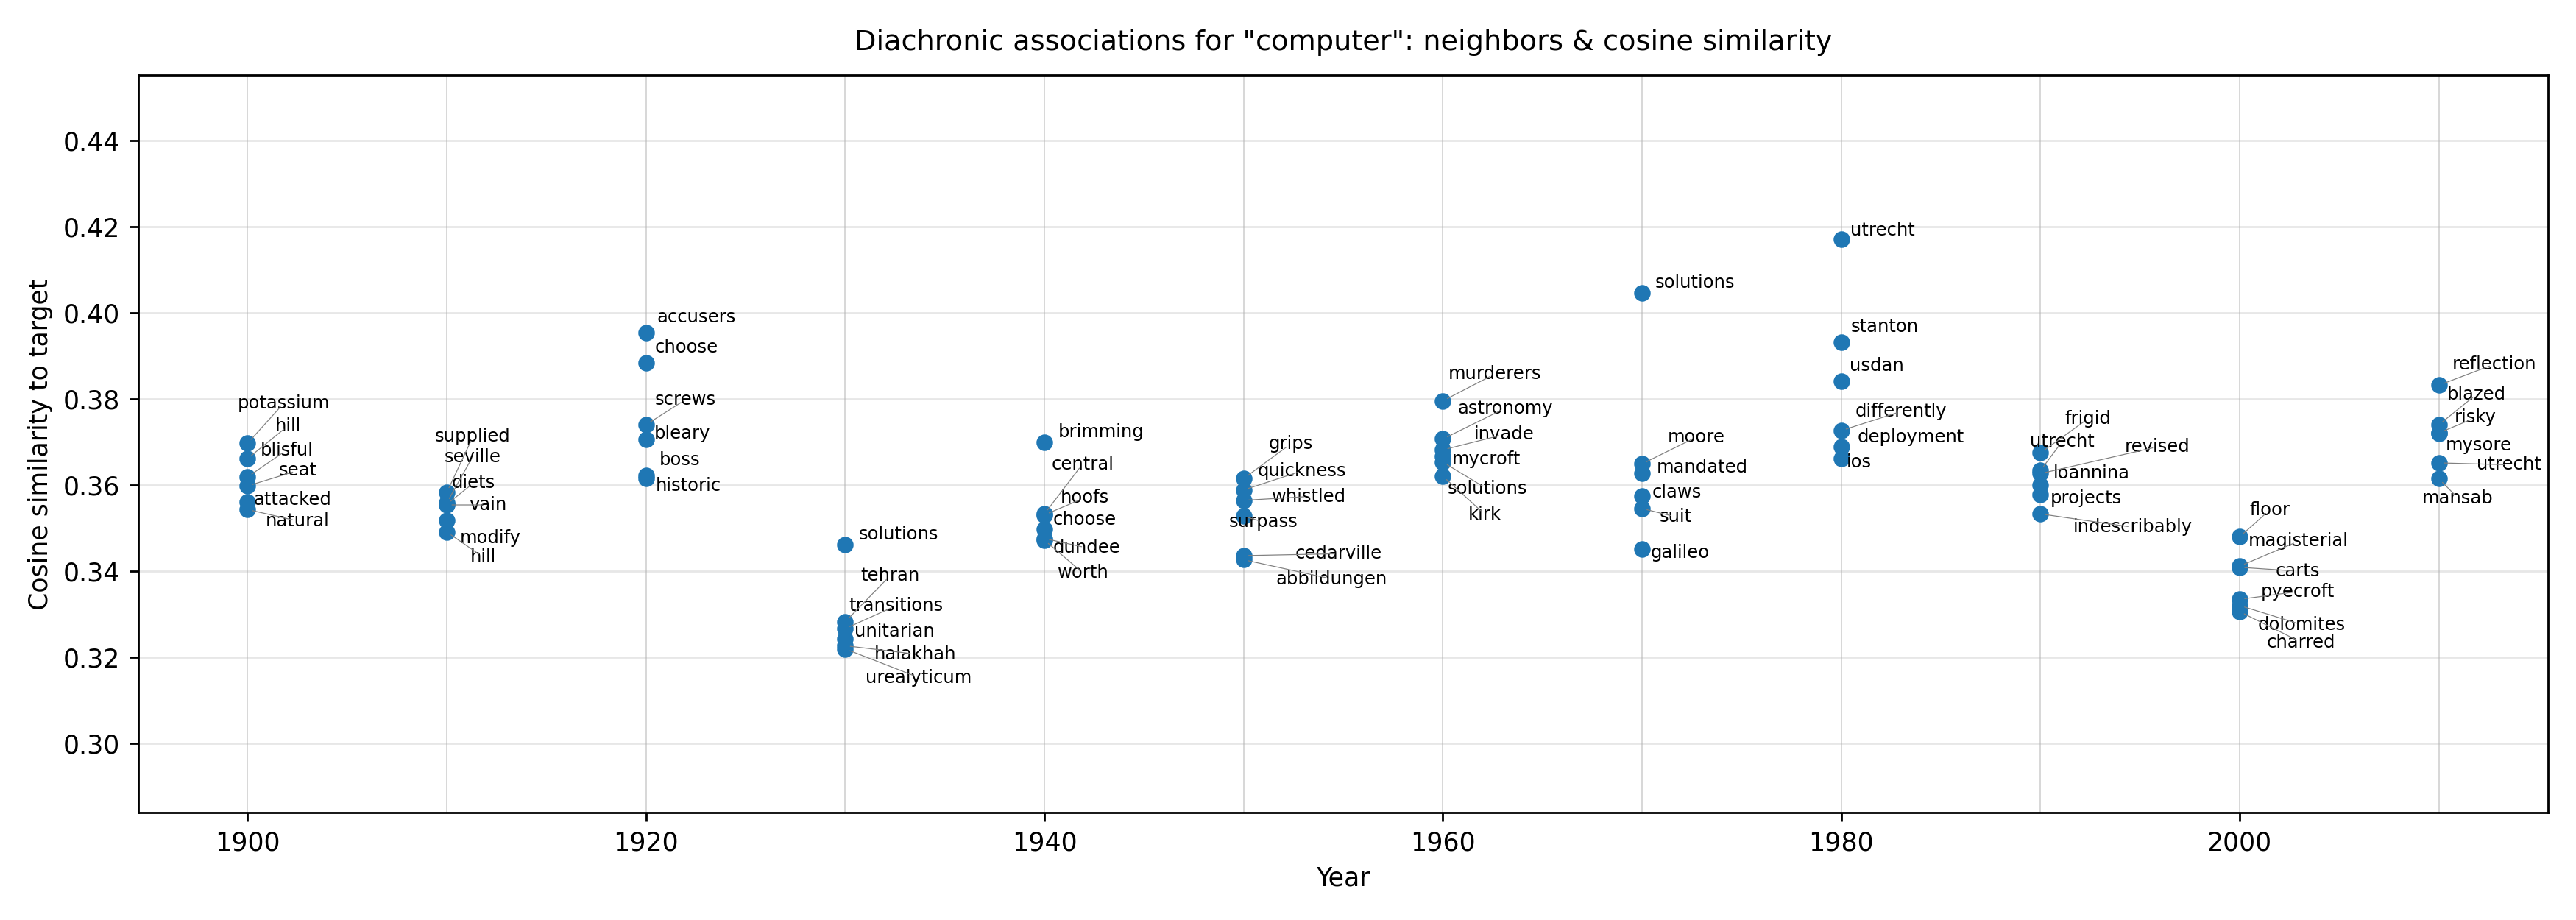

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_computer_1910s_1960s_top10.png


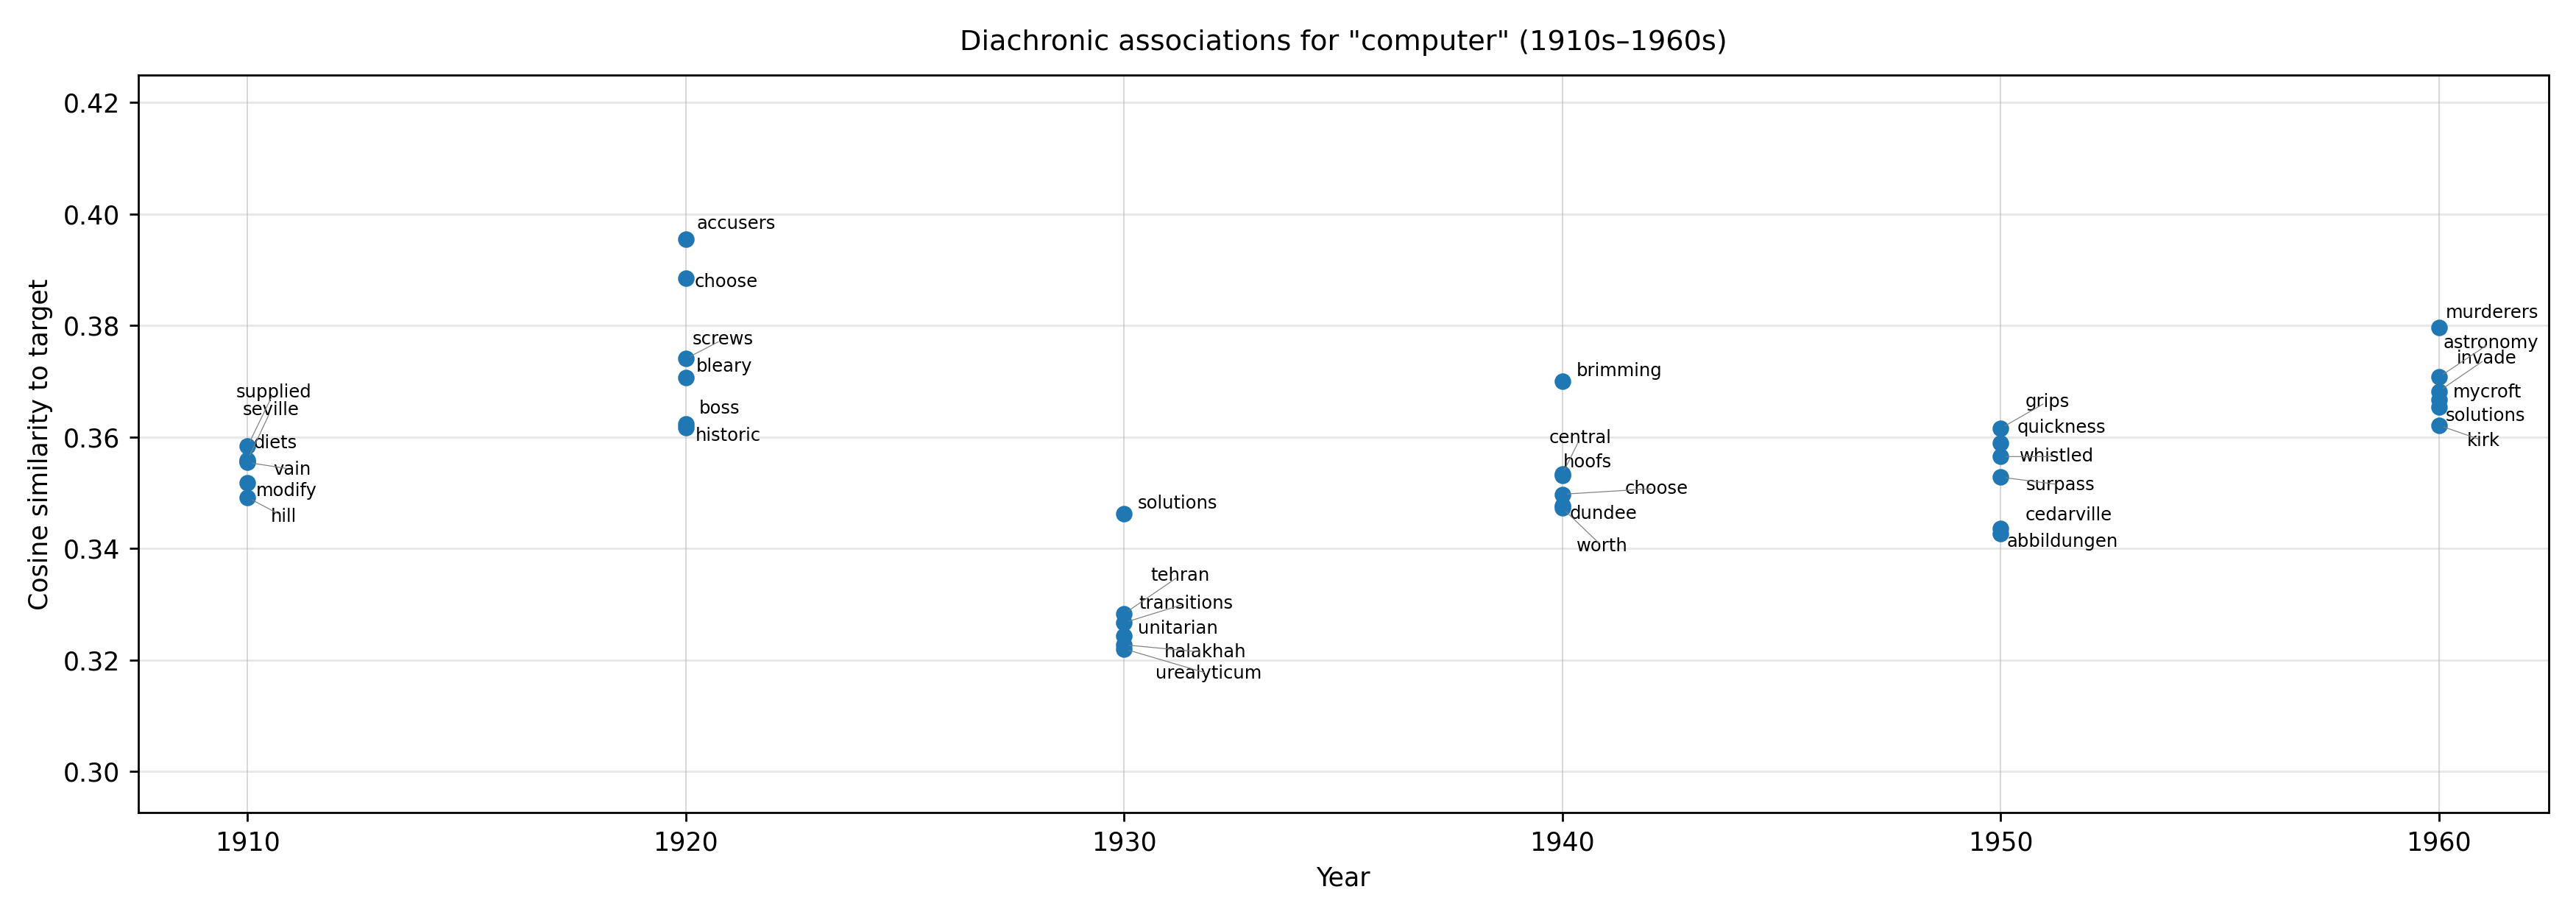

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_computer_1970s_2010s_top10.png


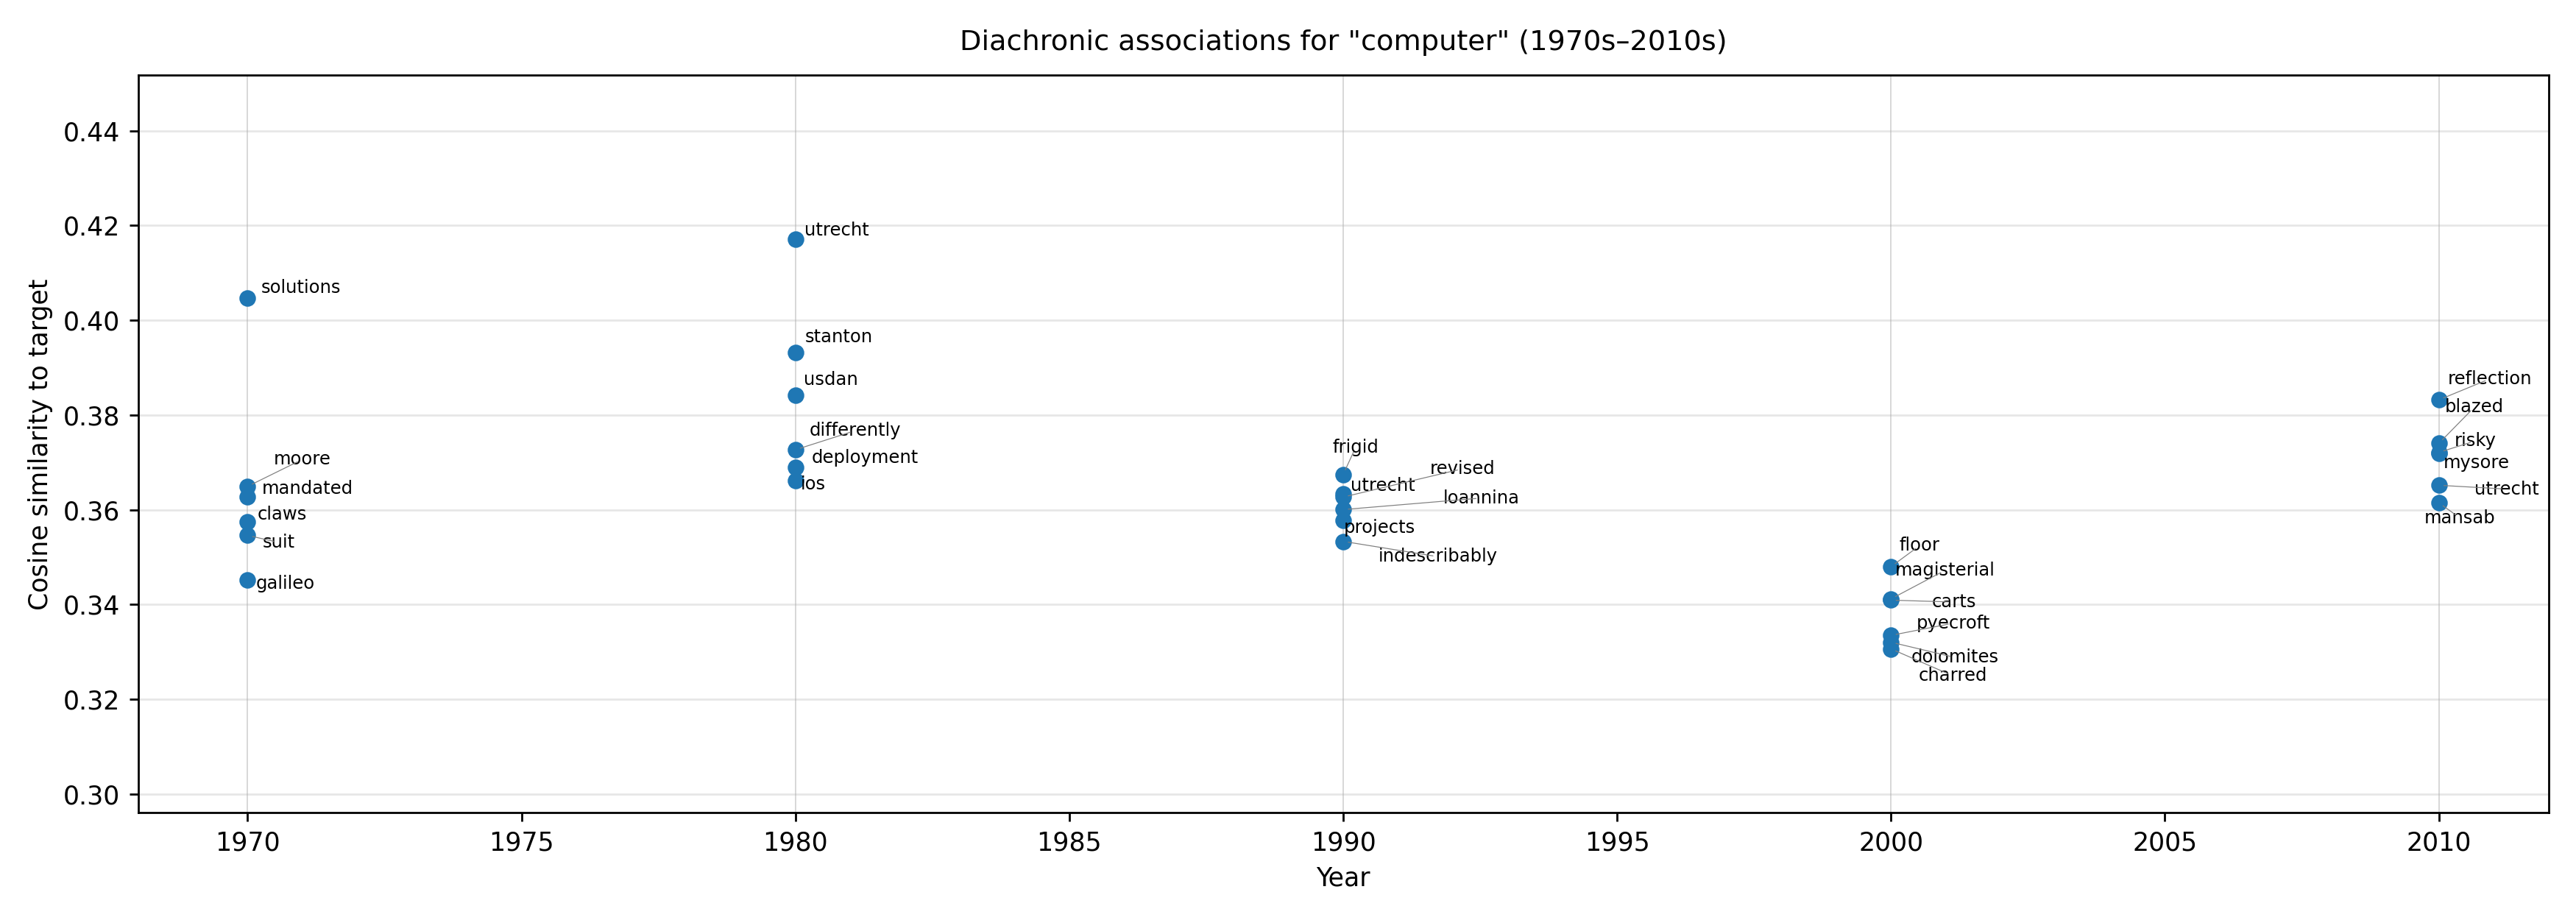

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_internet_ref_2010s_top10.png


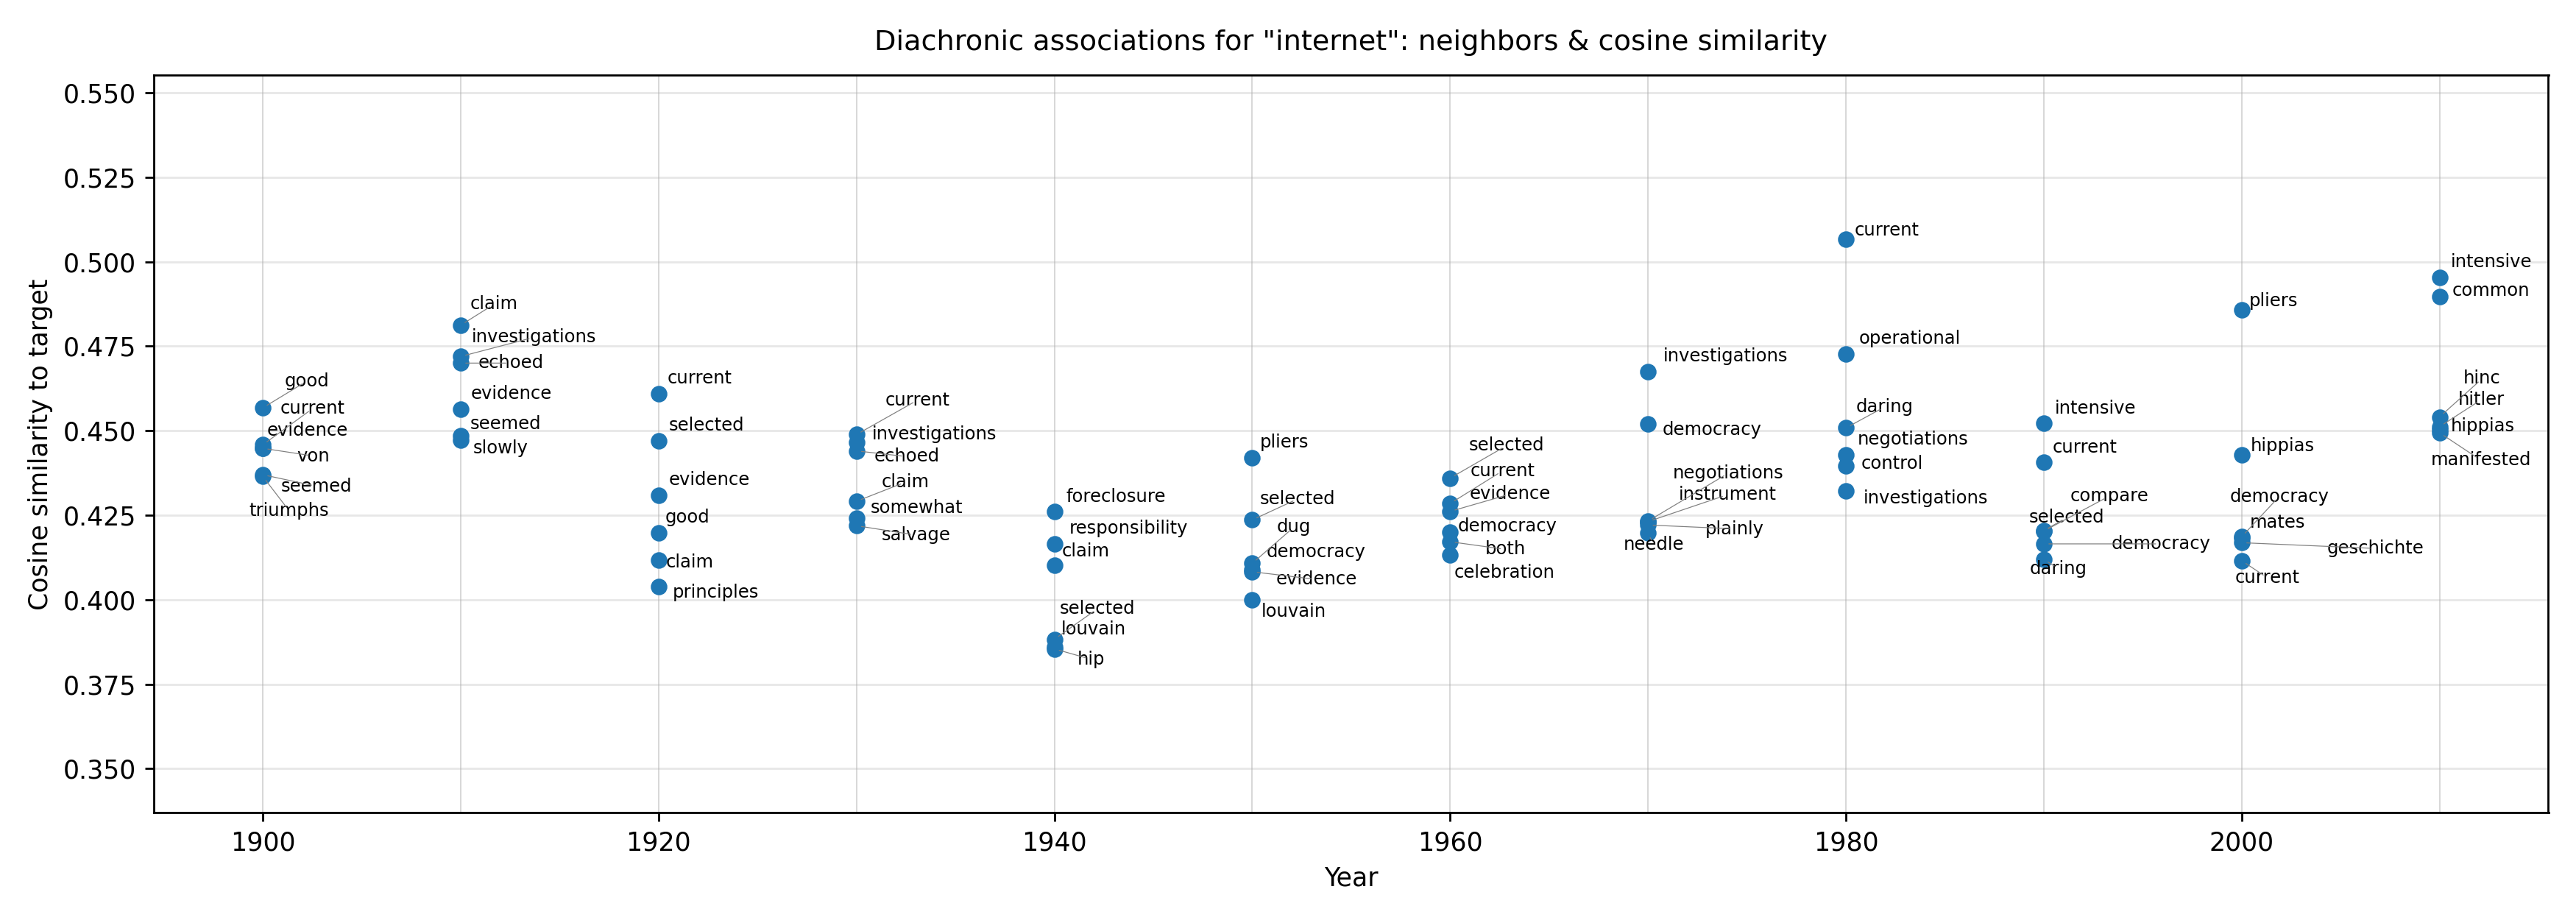

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_internet_1910s_1960s_top10.png


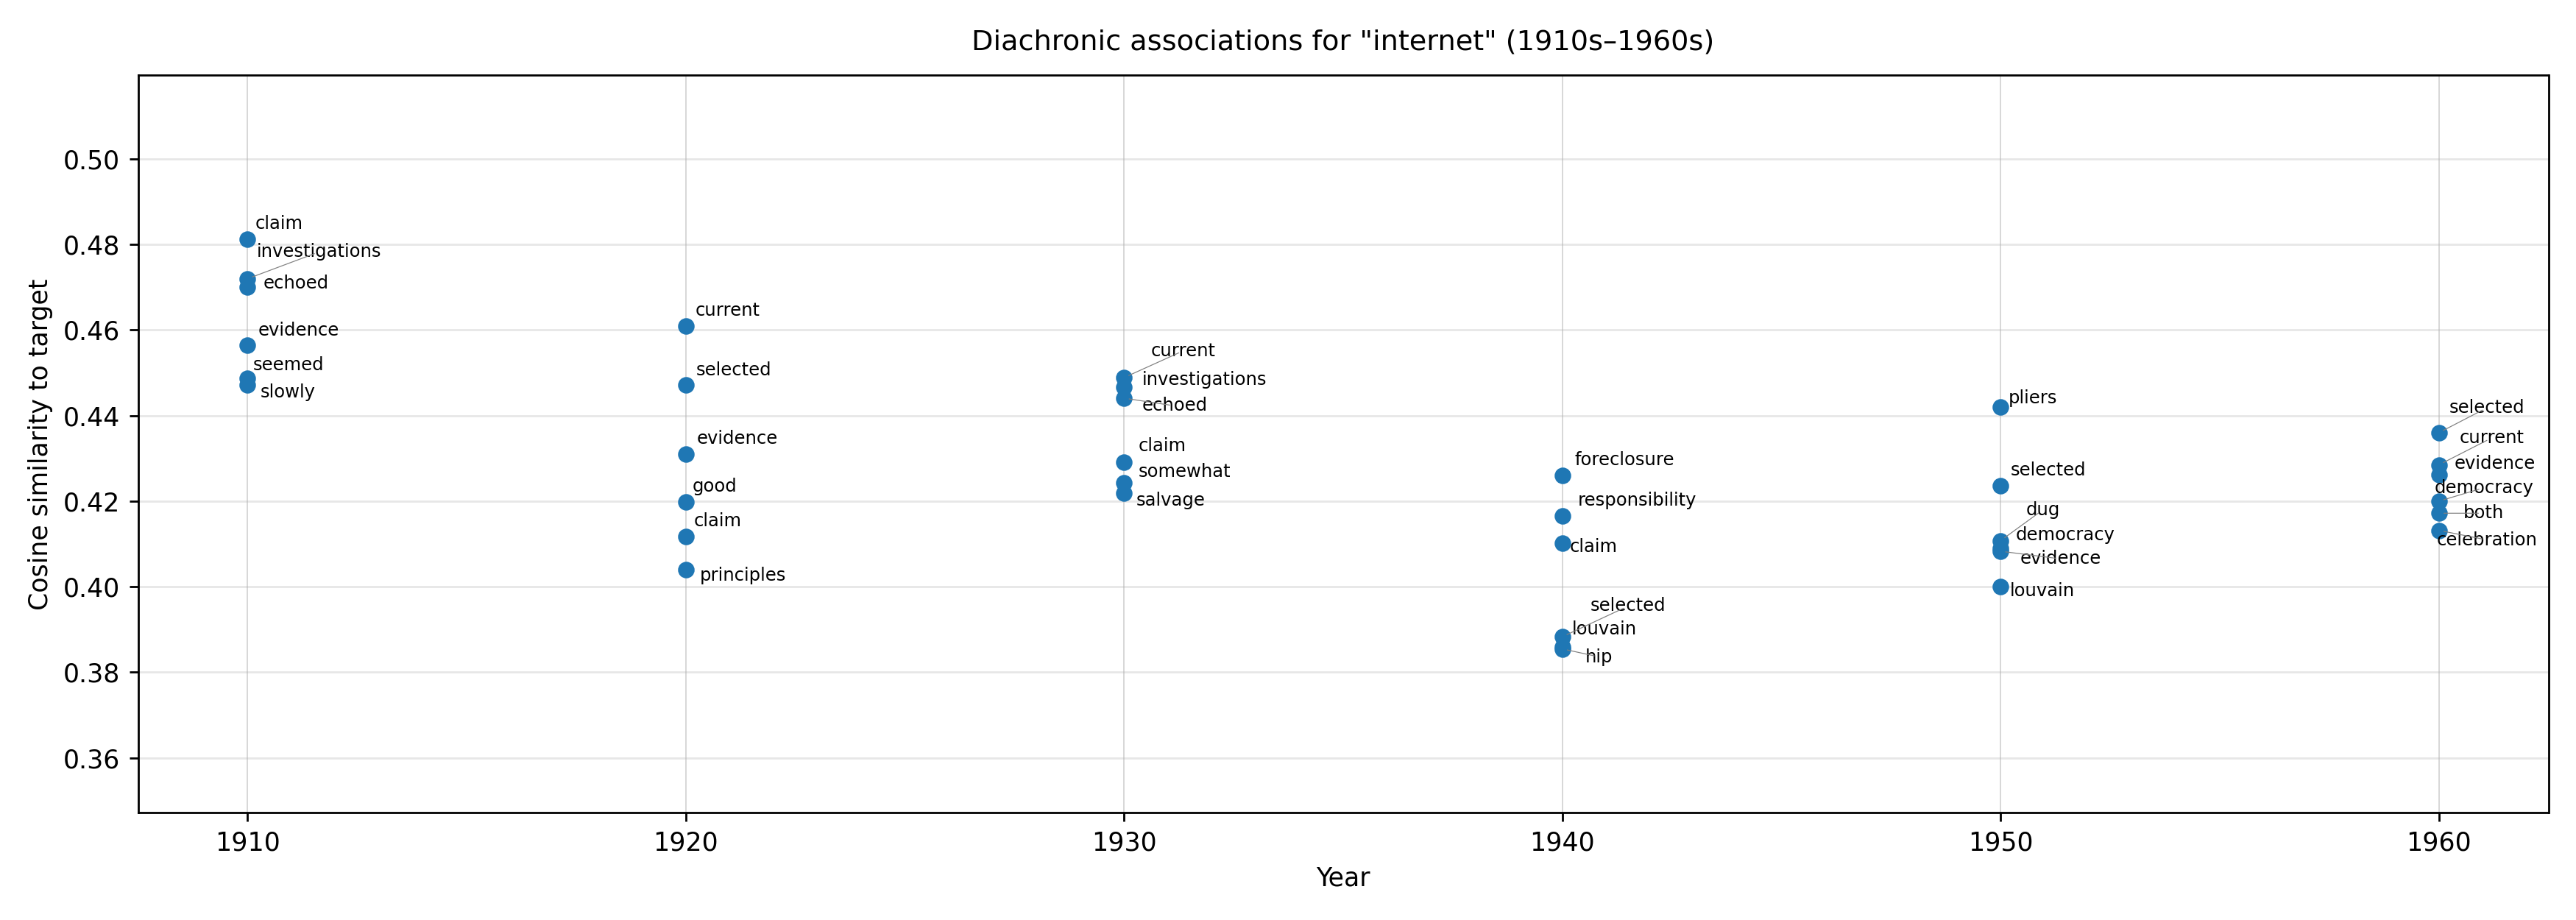

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_internet_1970s_2010s_top10.png


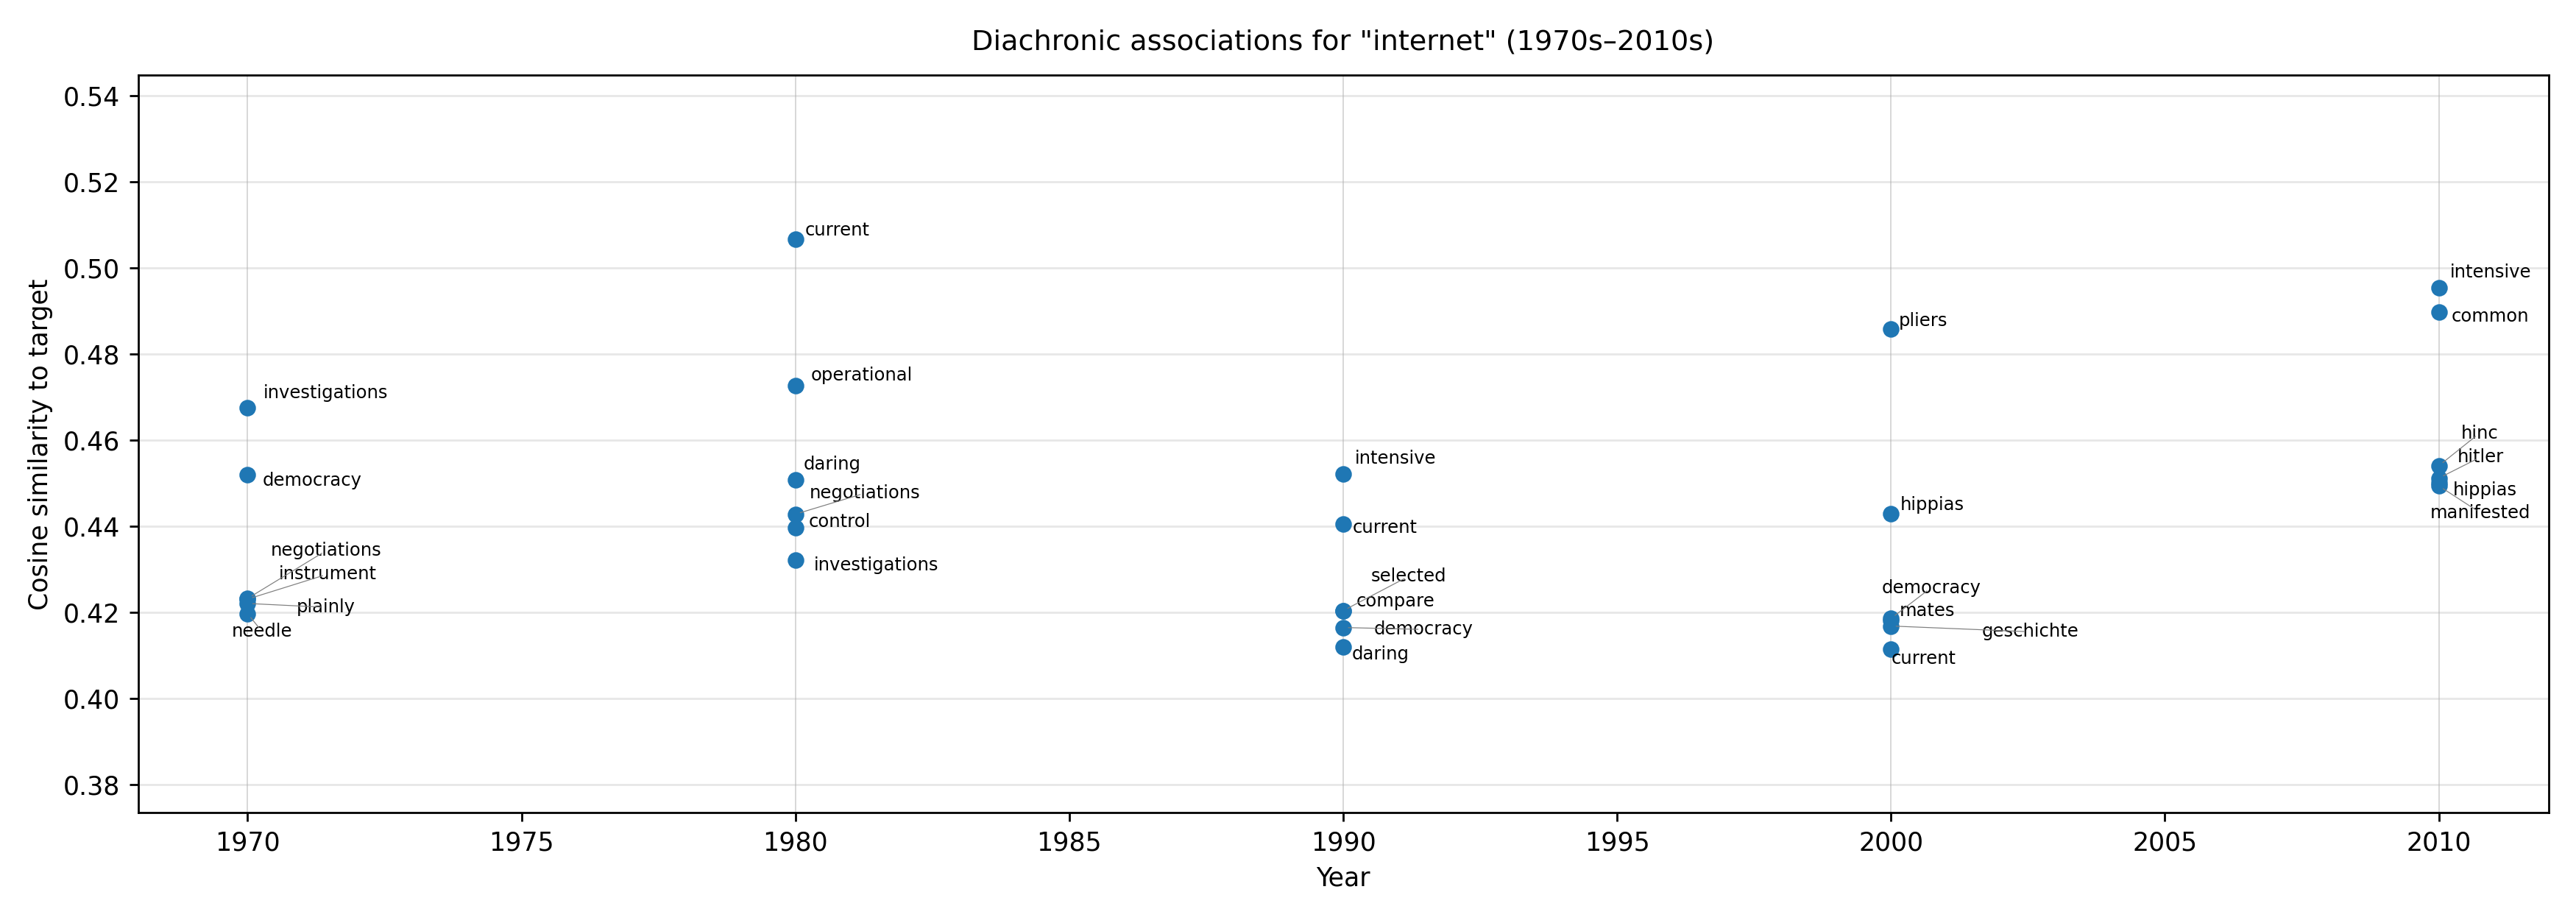

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_cloud_ref_2010s_top10.png


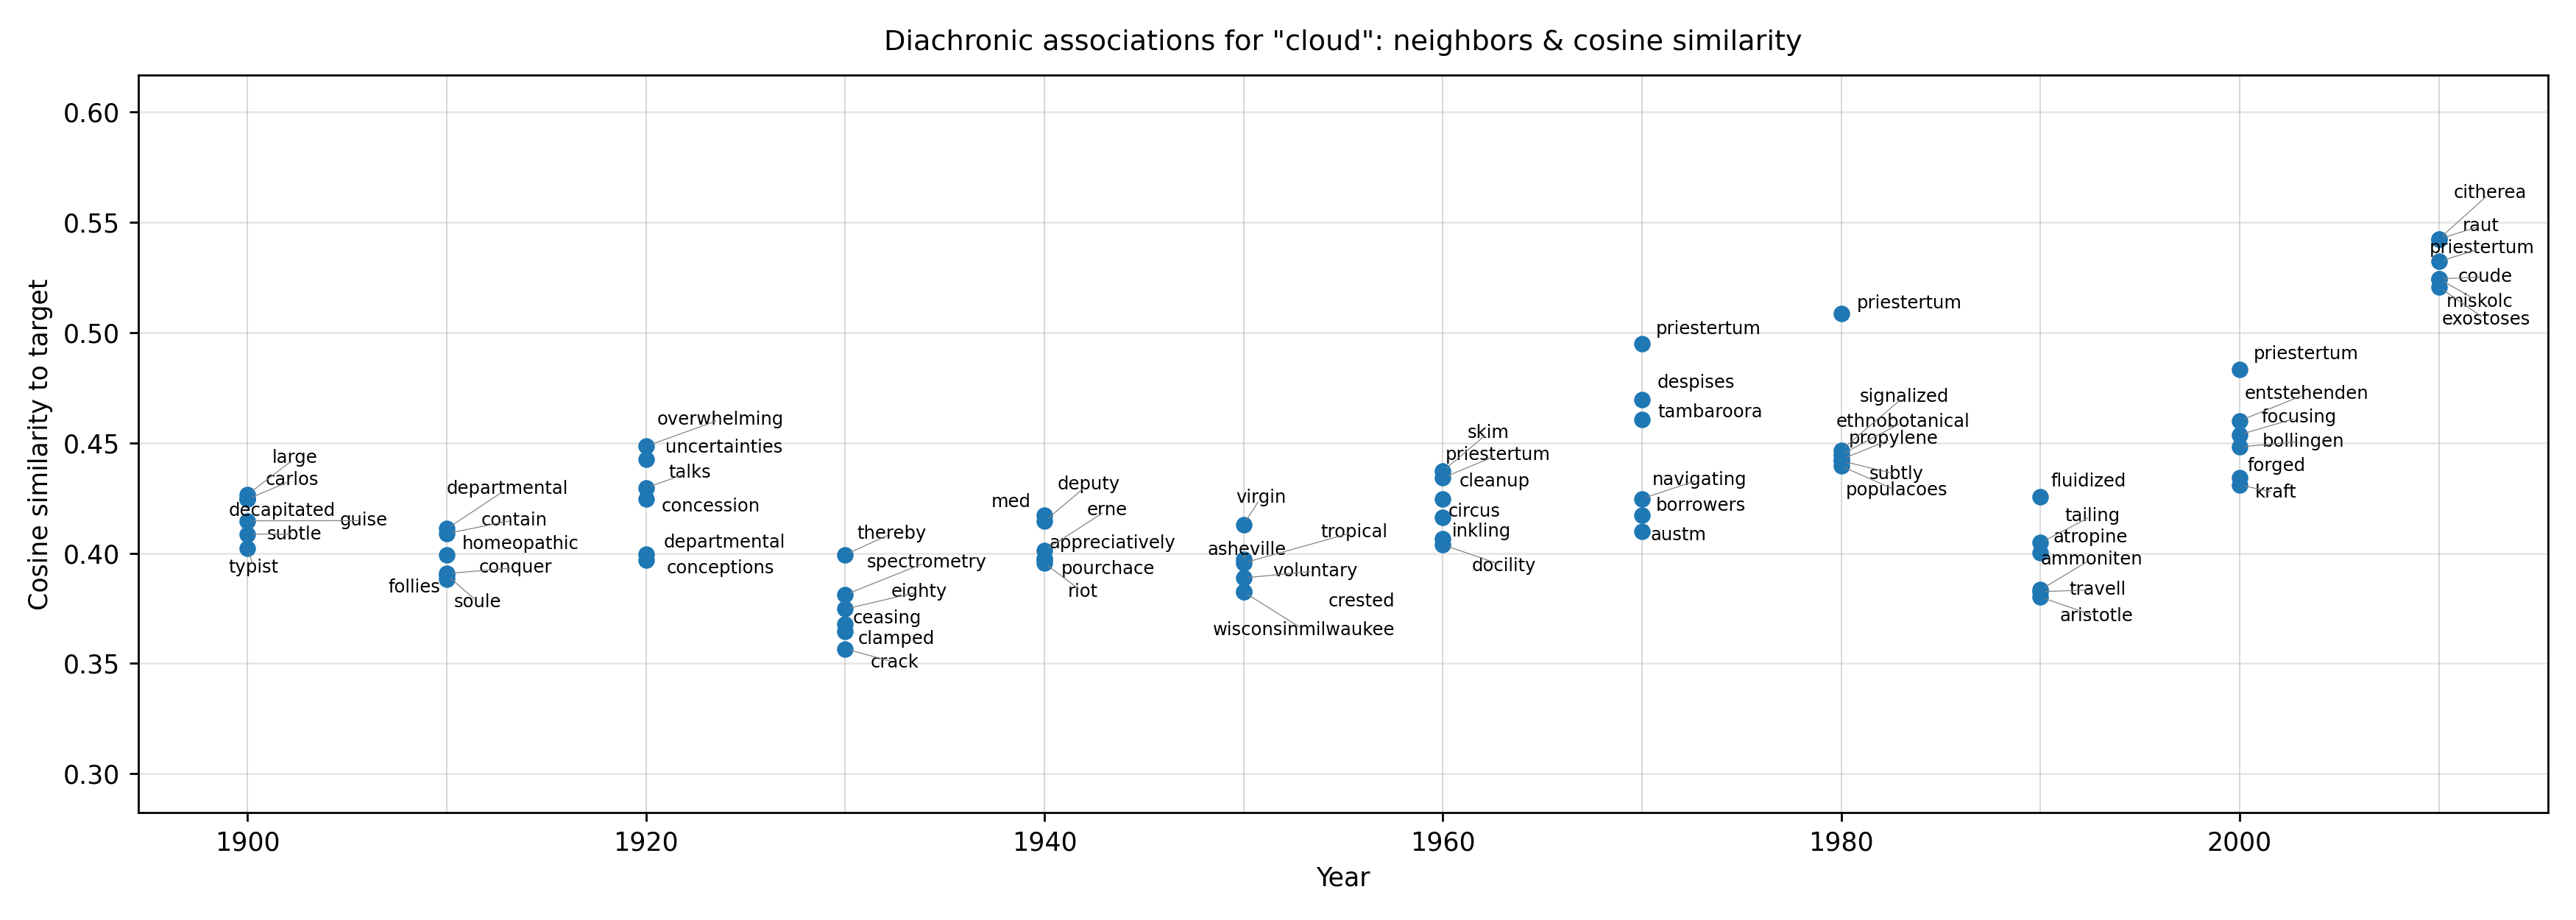

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_cloud_1910s_1960s_top10.png


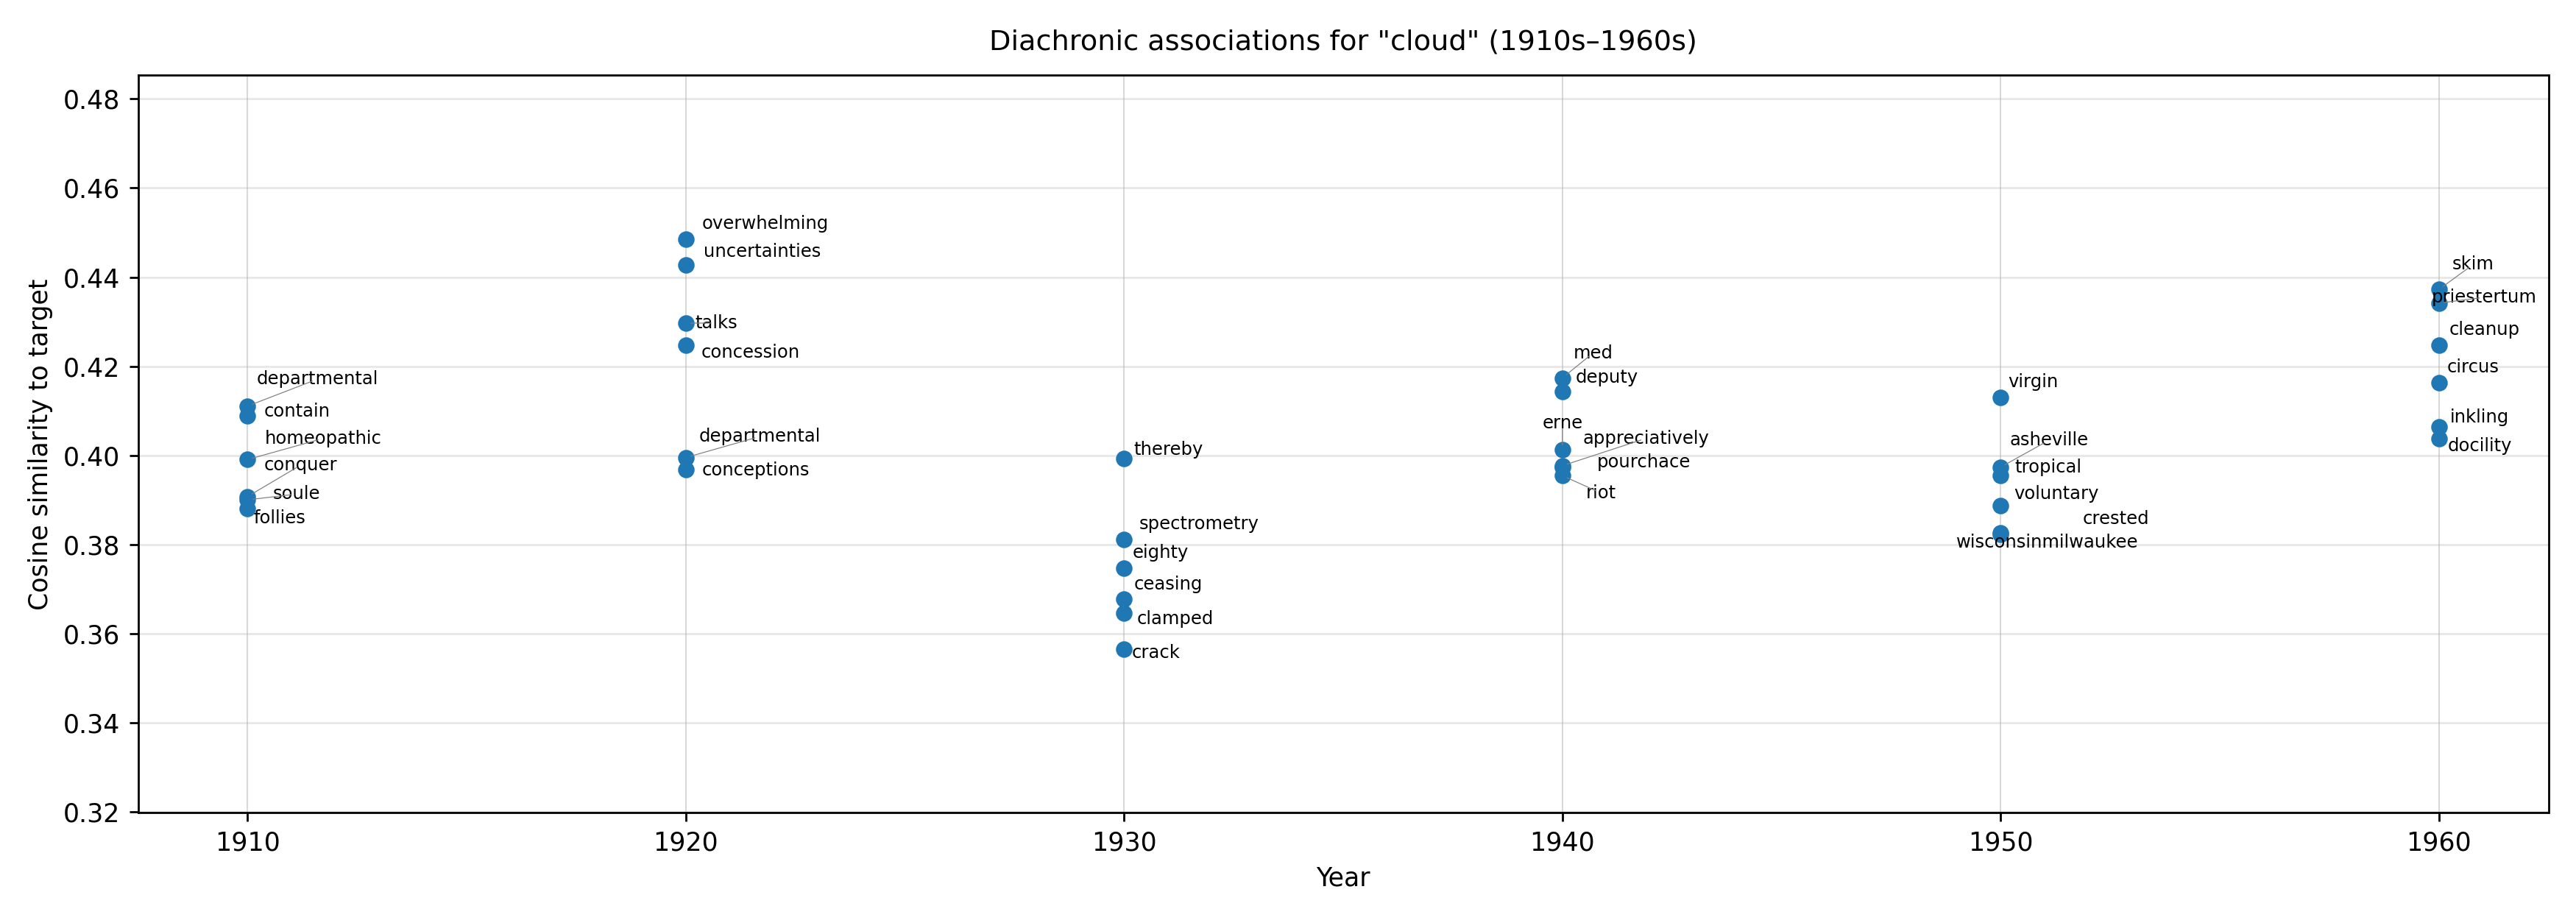

Diachronic associations plot saved → /home/sperrotta/diachronic_text_analysis/plots/diachronic_associations_cloud_1970s_2010s_top10.png


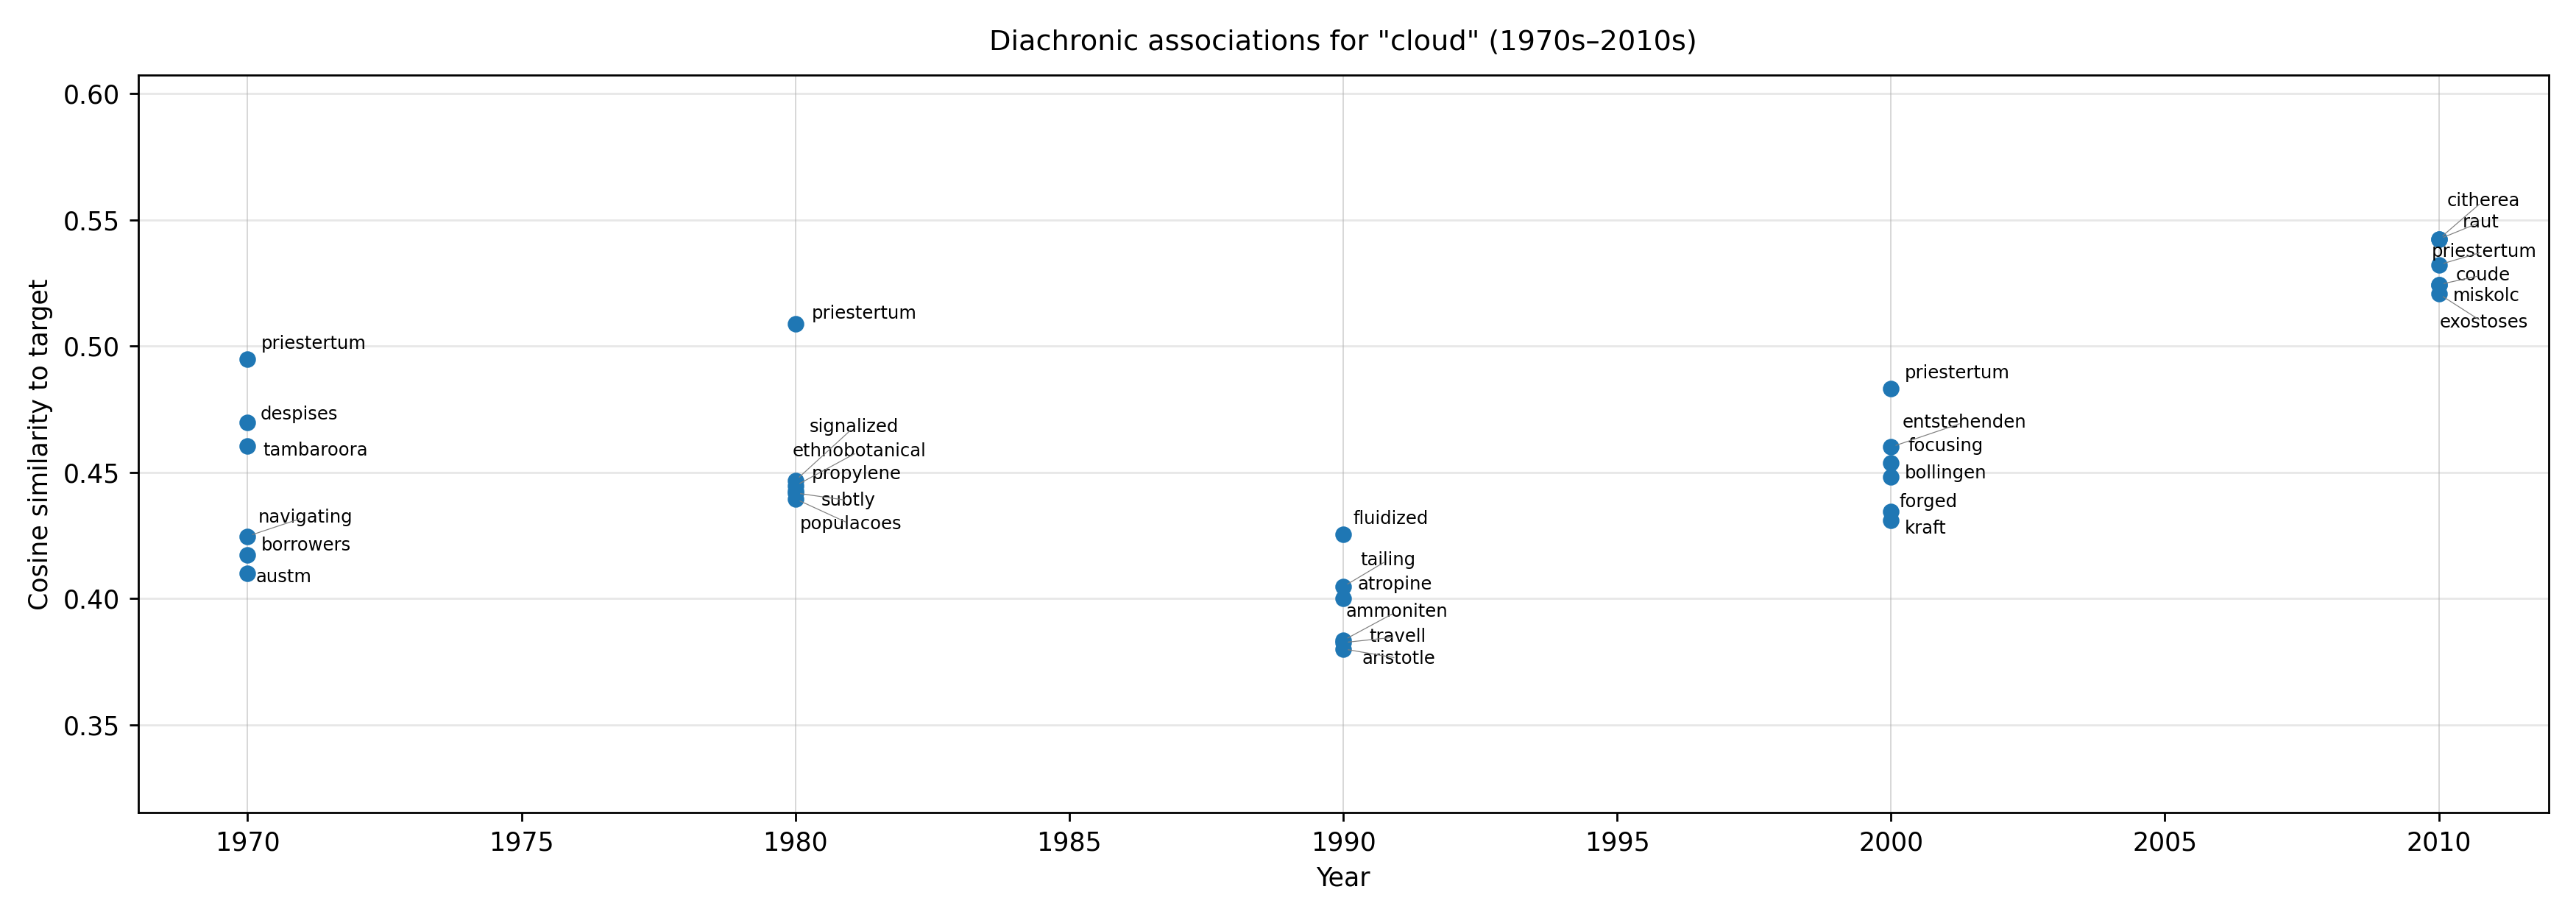

In [35]:
# Helper: filter rows to a decade window
def _filter_rows_window(rows, from_dec, to_dec):
    decs = list(DECADES)
    if from_dec: decs = decs[decs.index(from_dec):]
    if to_dec:   decs = decs[:decs.index(to_dec) + 1]
    return [r for r in rows if r["decade"] in decs]

from IPython.display import Image, display

# Run for each target word independently
for word in TARGET_WORDS:
    rows = compute_neighbors_over_time(
        word              = word,
        vocab             = vocab,
        inv_vocab         = inv_vocab,
        aligned_by_decade = aligned_by_decade,
        topk              = DIACHRONIC_TOPK,
    )

    # Write aggregated CSV for reproducibility
    out_csv = RESULTS_DIR / f"diachronic_neighbors_{word}_ref_{REFERENCE_DECADE}_top{TOP_K}.csv"
    with open(out_csv, "w", encoding="utf-8") as f:
        f.write("word,decade,year,rank,neighbor,cosine\n")
        for r in rows:
            f.write(f"{r['word']},{r['decade']},{r['year']},{r['rank']},{r['neighbor']},{r['cosine']}\n")

    # Full-range plot
    out_png = PLOTS_DIR / f"diachronic_associations_{word}_ref_{REFERENCE_DECADE}_top{TOP_K}.png"
    plot_diachronic_associations(
        rows    = rows,
        out_png = out_png,
        title   = f'Diachronic associations for "{word}": neighbors & cosine similarity',
    )
    display(Image(str(out_png)))

    # Per-window plots
    for (from_dec, to_dec) in DIACHRONIC_WINDOWS:
        rows_w   = _filter_rows_window(rows, from_dec, to_dec)
        tag_from = from_dec or DECADES[0]
        tag_to   = to_dec   or DECADES[-1]
        out_png_w = PLOTS_DIR / f"diachronic_associations_{word}_{tag_from}_{tag_to}_top{TOP_K}.png"
        plot_diachronic_associations(
            rows    = rows_w,
            out_png = out_png_w,
            title   = f'Diachronic associations for "{word}" ({tag_from}–{tag_to})',
        )
        display(Image(str(out_png_w)))

## Stage 11 — Stability / Dispersion Plot (`plot_stability_dispersion.py`)

This stage reads the neighbor CSVs produced in Stage 4 and plots an aggregated metric
of the top-K cosine similarity values over time — one line per target word.

The available metrics are:
- **`mean`** — average cosine similarity of the top-K neighbors: high values indicate
  a stable, coherent semantic neighbourhood; a declining trend signals drift
- **`std`** — standard deviation of the top-K cosine values: high values indicate a
  dispersed neighbourhood where neighbors vary widely in similarity
- **`cv`** — coefficient of variation (std / mean): normalised dispersion
- **`gap`** — max minus min cosine among the top-K: raw spread of the neighbourhood
- **`mean_top3`** — mean of the top-3 neighbors only: focuses on the closest context

`FROM_DECADE_STAB` / `TO_DECADE_STAB` optionally restrict the time window.
`RESULTS_DIRS` supports multiple directories for comparing different runs or models
side by side — each directory produces one line per word in the plot.

The output PNG is saved to `PLOTS_DIR` with filename:
`stability_dispersion_<metric>_top<K>_<from>_<to>_<words>.png`

Plot saved → /home/sperrotta/diachronic_text_analysis/plots/stability_dispersion_std_top10_1900s_2010s_computer_internet_cloud.png


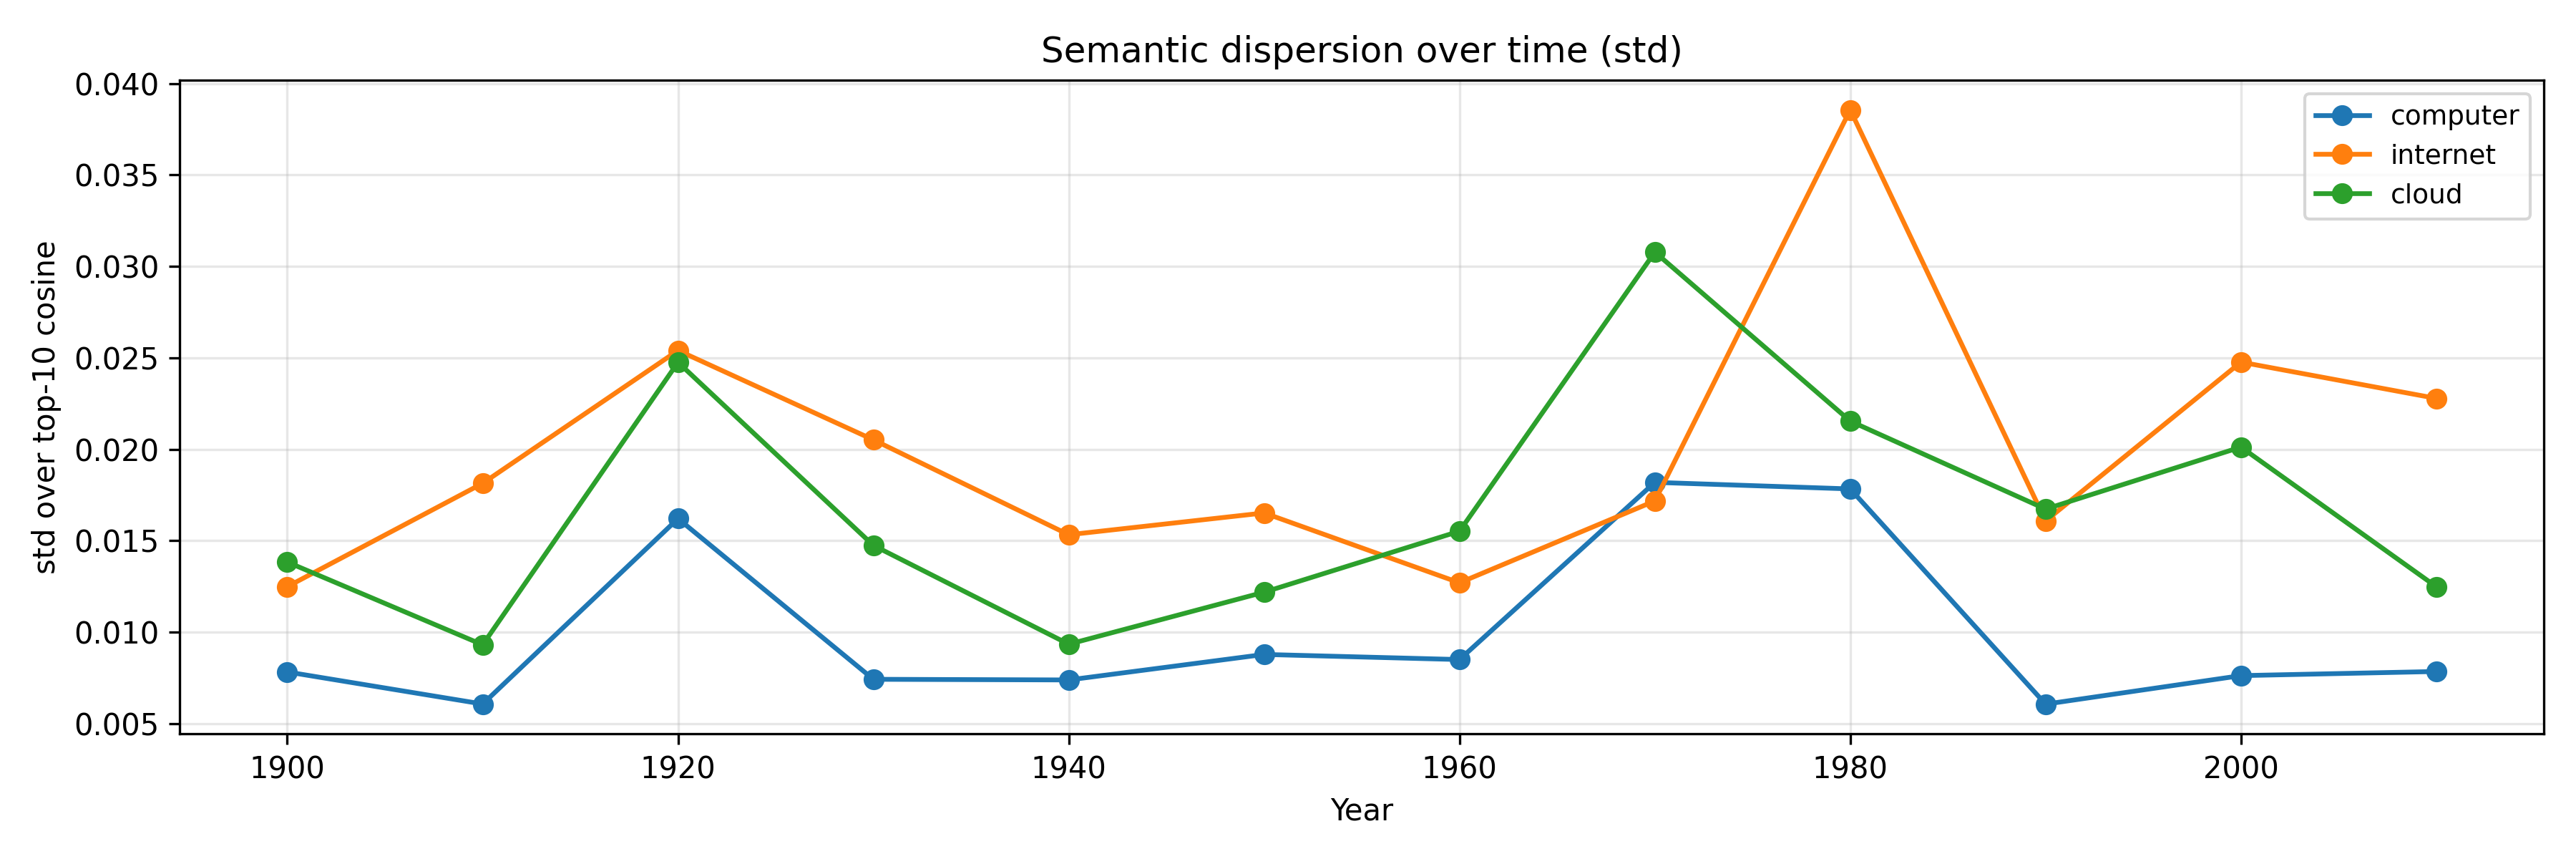

In [ ]:
# ── Parameters for this stage ────────────────────────────────────────────────
STAB_METRIC      = "std"       # mean | std | cv | gap | mean_top3
STAB_TOPK        = 10
FROM_DECADE_STAB = None        # e.g. "1970s" — None = all decades
TO_DECADE_STAB   = None        # e.g. "2010s" — None = all decades
RESULTS_DIRS     = [RESULTS_DIR]   # list of Path — one line per (dir, word)
RESULTS_LABELS   = ["results"]     # one label per dir

# ── Helpers ──────────────────────────────────────────────────────────────────
def _decade_slice_stab(from_dec, to_dec):
    decs = list(DECADES)
    if from_dec: decs = decs[decs.index(from_dec):]
    if to_dec:   decs = decs[:decs.index(to_dec) + 1]
    return decs

def _read_neighbors_csv_stab(csv_path):
    rows = []
    with open(csv_path, "r", encoding="utf-8") as f:
        f.readline()  # skip header
        for line in f:
            parts = line.strip().split(",")
            if len(parts) < 5: continue
            rows.append((parts[0], parts[1], int(parts[2]), parts[3], float(parts[4])))
    return rows

def _compute_metric(values, metric):
    v = values[np.isfinite(values)]
    if v.size == 0: return float("nan")
    if metric == "mean":     return float(v.mean())
    if metric == "std":      return float(v.std(ddof=0))
    if metric == "cv":       m = v.mean(); return float(v.std(ddof=0) / m) if m != 0 else float("nan")
    if metric == "gap":      return float(v.max() - v.min())
    if metric == "mean_top3":return float(np.sort(v)[::-1][:min(3, v.size)].mean())
    raise ValueError(f"Unknown metric: {metric}")

# ── Compute series ────────────────────────────────────────────────────────────
decs_stab  = _decade_slice_stab(FROM_DECADE_STAB, TO_DECADE_STAB)
years_stab = [decade_to_year(d) for d in decs_stab]
series_stab = {}

for run_dir, run_label in zip(RESULTS_DIRS, RESULTS_LABELS):
    rows_by_decade = {}
    for dec in decs_stab:
        csv_path = Path(run_dir) / f"neighbors_{dec}.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"Missing {csv_path} — run Stage 4 first.")
        rows_by_decade[dec] = _read_neighbors_csv_stab(csv_path)

    for w in TARGET_WORDS:
        y_vals = []
        for dec in decs_stab:
            vals = np.array([r[4] for r in rows_by_decade[dec]
                             if r[0] == w and r[2] <= STAB_TOPK], dtype=float)
            y_vals.append(_compute_metric(vals, STAB_METRIC))
        series_stab[(run_label, w)] = y_vals

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for (run_label, w), y_vals in series_stab.items():
    label = f"{w} ({run_label})" if len(RESULTS_DIRS) > 1 else w
    ax.plot(years_stab, y_vals, marker="o", linewidth=1.6, label=label)

ax.set_xlabel("Year")
ax.set_ylabel(f"{STAB_METRIC} over top-{STAB_TOPK} cosine")
ax.set_title(f"Semantic {'stability' if STAB_METRIC in ['mean','mean_top3'] else 'dispersion'} over time ({STAB_METRIC})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()

win   = f"{decs_stab[0]}_{decs_stab[-1]}"
words_tag = "_".join(TARGET_WORDS)
out_stab  = PLOTS_DIR / f"stability_dispersion_{STAB_METRIC}_top{STAB_TOPK}_{win}_{words_tag}.png"
fig.savefig(out_stab, dpi=300)
plt.close(fig)

print(f"Plot saved → {out_stab}")
from IPython.display import Image, display
display(Image(str(out_stab)))

## Output Summary

Complete inventory of all files produced by this notebook run.

In [ ]:
print("=== Plots (PLOTS_DIR) ===")
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(f"  {p.name}")

print("\n=== CSVs (RESULTS_DIR) ===")
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print(f"  {p.name}")

=== Plots (PLOTS_DIR) ===
  cosine_heatmap_cloud_ref_2010s.png
  cosine_heatmap_computer_ref_2010s.png
  cosine_heatmap_internet_ref_2010s.png
  diachronic_associations_cloud_1910s_1960s_top10.png
  diachronic_associations_cloud_1970s_2010s_top10.png
  diachronic_associations_cloud_ref_2010s_top10.png
  diachronic_associations_computer_1910s_1960s_top10.png
  diachronic_associations_computer_1970s_2010s_top10.png
  diachronic_associations_computer_ref_2010s_top10.png
  diachronic_associations_internet_1910s_1960s_top10.png
  diachronic_associations_internet_1970s_2010s_top10.png
  diachronic_associations_internet_ref_2010s_top10.png
  pca_cloud_ref_2010s_win_ALL_ALL.png
  pca_computer_internet_cloud_ref_2010s_win_ALL_ALL.png
  pca_computer_ref_2010s_win_ALL_ALL.png
  pca_internet_ref_2010s_win_ALL_ALL.png
  stability_dispersion_std_top10_1900s_2010s_computer_internet_cloud.png
  tsne_cloud_ref_2010s_perp_30.png
  tsne_computer_internet_cloud_ref_2010s_perp_30.png
  tsne_computer_ref_20